
# **<font color='purple'> `Part 3: Machine Learning Classifiers`</font>**
***
**Student**


|         Full name         |   Username  |         Email         |
|---------------------------|-------------|-----------------------|
| Emmanuel Nyandu Kagarabi  | emmanuelnk  | emmanuelnk@aims.ac.za |

<font color='teal'>`AI-Powered Classification and Early Detection of Dengue Lineages for a Timely Public Health Response`</font>

In [ ]:
# @title Zip and Download the Entire Content of the Current Virtual Machine Before Its Expiration
# 1. Zip
#!zip -r VM_4_COLAB_DATA.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2024.09.20/ (stored 0%)
  adding: content/.config/logs/2024.09.20/13.21.34.104159.log (deflated 58%)
  adding: content/.config/logs/2024.09.20/13.21.56.905204.log (deflated 56%)
  adding: content/.config/logs/2024.09.20/13.21.44.777817.log (deflated 85%)
  adding: content/.config/logs/2024.09.20/13.21.56.246468.log (deflated 57%)
  adding: content/.config/logs/2024.09.20/13.21.13.139283.log (deflated 93%)
  adding: content/.config/logs/2024.09.20/13.21.45.853413.log (deflated 58%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 23%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: co

In [ ]:
#2. Download
#from google.colab import files
#files.download('VM_4_COLAB_DATA.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# `0. Imports`

In [ ]:
#@title Installations
!pip install Bio
!pip install optuna
!pip install pandas biopython
!pip install scikit-learn
!pip install xgboost
!pip install hiclass
!pip install mmh3
!pip install dask[dataframe]
!pip install keras-self-attention
!pip install imbalanced-learn
# Clean installation outputs`
from IPython.display import clear_output
clear_output()

In [ ]:
#@title Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input, Conv1D,Conv2D,MaxPooling1D,MaxPooling2D, Flatten,BatchNormalization,GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.preprocessing.sequence import pad_sequences
import requests
from Bio import SeqIO, Phylo
import prince
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
import re
import os
import sys
import zipfile
from sklearn import tree
from scipy.fftpack import fft
import mmh3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, roc_curve, auc, classification_report)
from xgboost import XGBClassifier
import lightgbm as lgb
# Hicall
from hiclass import (LocalClassifierPerNode, LocalClassifierPerParentNode, LocalClassifierPerLevel)
import hiclass.metrics as hm
#from sklearn.utils.multiclass import unique_label
from scipy.stats import entropy
from datetime import datetime
from random import shuffle
import joblib
%matplotlib inline
import time
from keras_self_attention import SeqSelfAttention #Import the SeqSelfAttention layer
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Random Sampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from itertools import cycle

import warnings
warnings.filterwarnings("ignore")
now = datetime.now()
now.strftime("%H:%M:%S")

'09:11:20'

# `I. Datasets`

In [ ]:
df = pd.read_csv('/content/df_final_dengue_dataset.csv')
df.head()

,Sequence,Length,Serotype,Lineage,Lineage_Label,Taxonomic_Lineage,Hierarchy,Collection date,Submission date,Location
0,TAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGCTTGCT...,10652,DENV1,1I_K.2,5,1_I_K_2,"['1', 'I', 'K', '2']",2022-05-24,2023-11-16,Asia / Indonesia / Bali
1,CGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGT...,10490,DENV2,2II_F.1.2,20,2_II_F_1.2,"['2', 'II', 'F', '1.2']",2024-03-22,2024-05-24,South America / Ecuador / Loja
2,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,10461,DENV3,3III_B.3,24,3_III_B_3,"['3', 'III', 'B', '3']",2023-06-08,2023-10-10,North America / USA / Florida
3,CACAGTTGGCGAAGAGATTCTCAAAAGGATTGCTGAACGGCCAGGG...,10393,DENV3,3III_C.2,26,3_III_C_2,"['3', 'III', 'C', '2']",2022-09-27,2023-05-20,North America / Mexico / Veracruz
4,TTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATT...,10087,DENV1,1V_D.1,7,1_V_D_1,"['1', 'V', 'D', '1']",2020-12-18,2023-04-13,North America / USA / Florida


# `II. Machine Learning task : Classification`

# `II.1. Feature extraction techniques`

In [ ]:
# This function performs the k-mer technique:
def get_kmers(sequence, k):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# This function performs the FCGR:
def fcgr(sequence, resolution):
    grid = np.zeros((resolution, resolution))
    x, y = 0.5, 0.5
    for nucleotide in sequence:
        if nucleotide == 'A':
            x, y = x / 2, y / 2
        elif nucleotide == 'C':
            x, y = x / 2, (y + 1) / 2
        elif nucleotide == 'G':
            x, y = (x + 1) / 2, (y + 1) / 2
        elif nucleotide == 'T':
            x, y = (x + 1) / 2, y / 2
        grid[int(x * resolution), int(y * resolution)] += 1
    return grid.flatten()

# `II.2. Training with only optimal parameters`

# `II.2.1. K-mers encoding`

**(A) Understand Hierarchical Classification in depth**

In [ ]:
#@title A.1. Dummy dataset : Metrics(hm.precision, hm.recall, hm.f1), Label = 1I_A.2.1
true_sample_1 = [["1", "I","A", "2.1"]]
predicted_1 = [["1", "I","B",""]]

# Compute hierarchical metrics
print(f'Hierarchical Precision = {hm.precision(true_sample_1, predicted_1)}')
print(f'Hierarchical Recall = {hm.recall(true_sample_1, predicted_1)}')
print(f'Hierarchical F1 = {hm.f1(true_sample_1, predicted_1)}')

Hierarchical Precision = 0.6666666666666666
Hierarchical Recall = 0.5
Hierarchical F1 = 0.5714285714285715


In [ ]:
#@title A.2. Apply 5-mers as Feature extraction Technique plus SMOTE for flat classifiers
k=5
# Convert sequences to k-mers and apply CountVectorizer
df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
vectorizer = CountVectorizer()
X_kmers = vectorizer.fit_transform(df['kmers']).astype(np.float32)

# Encode labels for flat classifier
label_encoder = LabelEncoder()
df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
y_flat = df['Lineage_Label']

print("Original class distribution:")
print(Counter(y_flat))

# Creating hierarchical labels
df['Hierarchy'] = df['Taxonomic_Lineage'].apply(lambda x: x.split('_'))
y_hierarchy = df['Hierarchy'].tolist()  # Ensure it's a list of lists

# Train/test split
X_train, X_test, y_train_flat, y_test_flat = train_test_split(X_kmers, y_flat, test_size=0.2, random_state=42)
X_train_hier, X_test_hier, y_train_hier, y_test_hier = train_test_split(X_kmers, y_hierarchy, test_size=0.2, random_state=42)

# Apply SMOTE for flat classifiers
smote = SMOTE(random_state=42)
X_train_resampled, y_train_flat_resampled = smote.fit_resample(X_train, y_train_flat)

print("\nResampled class distribution:")
print(Counter(y_train_flat_resampled))

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({19: 544, 4: 544, 7: 544, 8: 544, 20: 544, 24: 544, 28: 544, 1: 544, 14: 544, 36: 544, 15: 544, 33: 544, 35: 544, 9: 544, 18: 544, 25: 544, 3: 544, 34: 544, 6: 544, 10: 544, 31: 544, 11: 544, 21: 544, 17: 544, 27: 544, 32: 544, 22: 544, 30: 544, 5: 544, 29: 544, 0: 544, 2: 544, 16: 544, 37: 544, 12: 544, 23: 544, 13: 544, 26: 544})


In [ ]:
# @title
# Current dataset: drop K-mers column
# df.drop('kmers', axis=1, inplace=True)
# df = df[['Sequence','Length','Serotype','Lineage','Lineage_Label','Taxonomic_Lineage','Hierarchy', 'Collection date','Submission date','Location']]
# save the current dataset
# df.to_csv('/content/df_final_dengue_dataset.csv', index=False)
# df.head()

In [ ]:
#@title A.3. Training

# Flat Classifiers
flat_classifiers = {
    'Flat RF': RandomForestClassifier(n_estimators=234, max_depth=19, min_samples_split=17, min_samples_leaf=16,
                                      bootstrap=True, criterion='gini', n_jobs=-1, random_state=42)
}

# Hierarchical Classifiers
rf_classifier = RandomForestClassifier(n_estimators=234, max_depth=19, min_samples_split=17, min_samples_leaf=16,
                                      bootstrap=True, criterion='gini', n_jobs=-1, random_state=42)
hierarchical_classifiers = {
    'LCPN RF': LocalClassifierPerParentNode(local_classifier=rf_classifier),
    'LCL RF': LocalClassifierPerLevel(local_classifier=rf_classifier),
    'LCN RF': LocalClassifierPerNode(local_classifier=rf_classifier)
}

# Fit hierarchical classifiers
for clf in hierarchical_classifiers.values():
    clf.fit(X_train_hier, y_train_hier)

# Predict hierarchical classifiers
predictions_hier = {name: clf.predict(X_test_hier) for name, clf in hierarchical_classifiers.items()}

# Calculate hierarchical metrics
hierarchical_metrics = {
    'Accuracy': [0, 0, 0],
    'MCC': [0, 0, 0],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

for name, preds in predictions_hier.items():
    hR = hm.recall(y_test_hier, preds)
    hP = hm.precision(y_test_hier, preds)
    hF = hm.f1(y_test_hier, preds)
    hierarchical_metrics['Precision'].append(hP)
    hierarchical_metrics['Recall'].append(hR)
    hierarchical_metrics['F1 Score'].append(hF)

# Collect flat classifier scores
flat_metrics = {
    'Accuracy': accuracy_score,
    'F1 Score': f1_score,
    'MCC': matthews_corrcoef,
    'Precision': precision_score,
    'Recall': recall_score
}

flat_scores = {name: [] for name in flat_metrics.keys()}
for clf_name, clf in flat_classifiers.items():
    clf.fit(X_train_resampled, y_train_flat_resampled)
    y_pred = clf.predict(X_test)
    for metric_name, metric in flat_metrics.items():
        if metric_name in ['F1 Score', 'Precision', 'Recall']:
            flat_scores[metric_name].append(metric(y_test_flat, y_pred, average='macro', zero_division=0))
        else:
            flat_scores[metric_name].append(metric(y_test_flat, y_pred))

In [ ]:
#@title A.4. Define levels

# Classifier names for labeling
classifier_names = list(hierarchical_classifiers.keys())

# Define metrics and levels for labels
metrics = ['Precision', 'Recall', 'F1 Score']
levels = ['Serotype', 'Genotype', 'Major Lineage', 'Minor Lineage']
n_levels = len(levels)

# Initialize dictionary to hold hierarchical metrics per level
hierarchical_metrics_per_level = {level: {'Precision': [], 'Recall': [], 'F1 Score': []} for level in levels}

# Calculate hierarchical metrics for each classifier at each level
for name, preds in predictions_hier.items():
    for i, level in enumerate(levels):
        # Extract true and predicted labels at the current level
        true_level_labels = [true[i] if i < len(true) else None for true in y_test_hier]
        pred_level_labels = [pred[i] if i < len(pred) else None for pred in preds]

        # Calculate hierarchical metrics at this level
        hR = hm.recall(true_level_labels, pred_level_labels)
        hP = hm.precision(true_level_labels, pred_level_labels)
        hF = hm.f1(true_level_labels, pred_level_labels)

        # Store metrics
        hierarchical_metrics_per_level[level]['Precision'].append(hP)
        hierarchical_metrics_per_level[level]['Recall'].append(hR)
        hierarchical_metrics_per_level[level]['F1 Score'].append(hF)

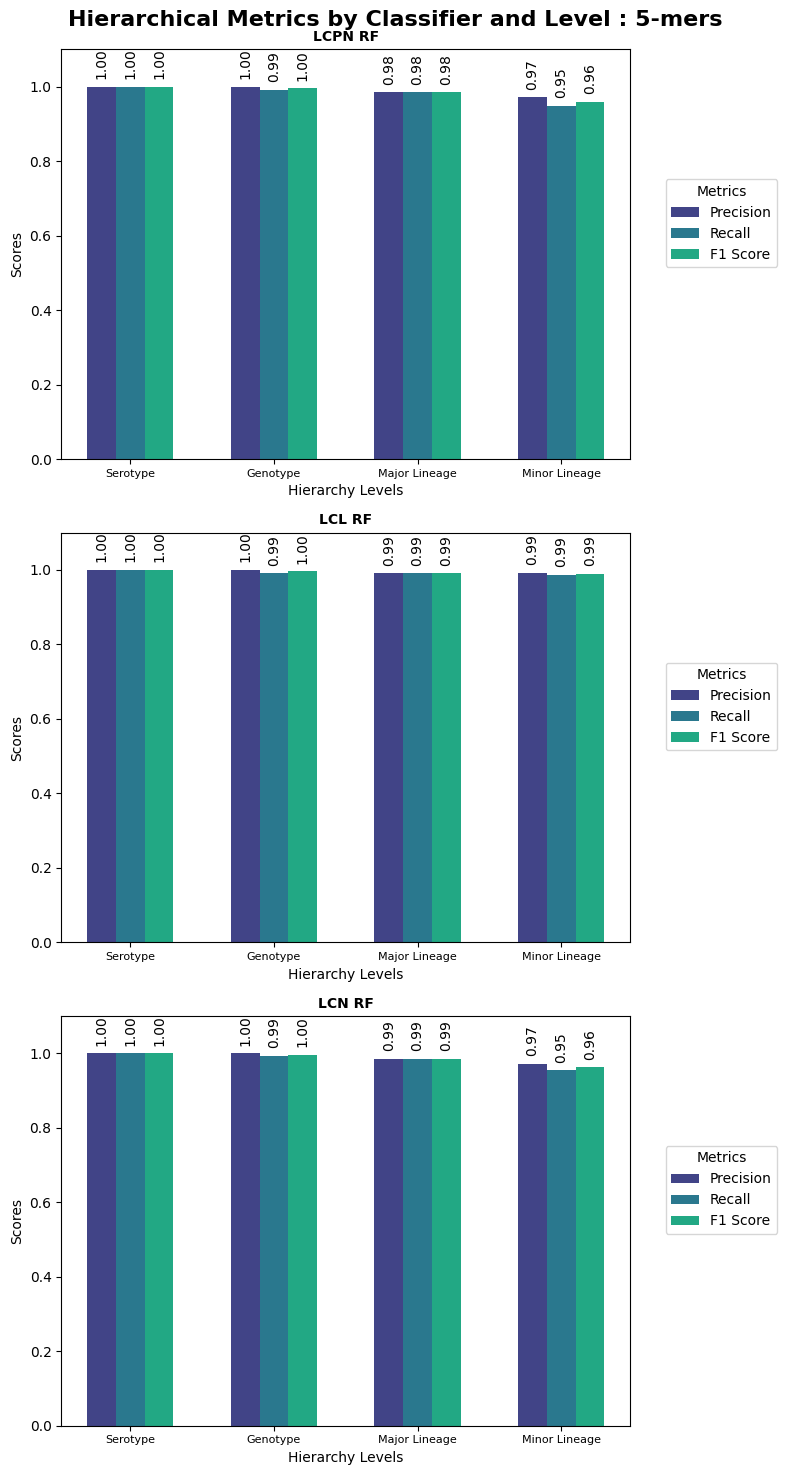

In [ ]:
#@title A.5. Display plots

# Set up the plot with subplots for each classifier
fig, axes = plt.subplots(len(classifier_names), 1, figsize=(8, 15), sharex=False, sharey=False)
fig.suptitle(f"Hierarchical Metrics by Classifier and Level : {k}-mers", fontsize=16, fontweight='bold')
bar_width = 0.2
colors = sns.color_palette("viridis", n_levels)

# Create subplots for each hierarchical classifier
for idx, (ax, clf_name) in enumerate(zip(axes, classifier_names)):
    # Plot each metric as grouped bars for each level
    for metric_idx, metric in enumerate(metrics):
        # Extract metric values for the current classifier and metric
        values = [hierarchical_metrics_per_level[level][metric][idx] for level in levels]

        # Set bar positions
        bar_positions = np.arange(n_levels) + (metric_idx * bar_width)

        # Plot bars with annotations
        bars = ax.bar(bar_positions, values, bar_width, label=metric, color=colors[metric_idx])

        # Annotate values on top of each bar
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # Center of bar
                bar.get_height() + 0.02,            # Slightly above bar
                f"{value:.2f}",                     # Display value
                ha="center", va="bottom", rotation=90, fontsize=10)

    # Formatting each subplot
    ax.set_title(f"{clf_name}", fontsize=10, fontweight='bold')
    ax.set_xticks(np.arange(n_levels) + bar_width)
    ax.set_xticklabels(levels,fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Hierarchy Levels', fontsize=10)
    ax.set_ylabel('Scores', fontsize=10)
    ax.legend(title="Metrics", bbox_to_anchor=(1.05, 0.7), loc="upper left", fontsize=10)

# Final adjustments
plt.tight_layout()
plt.show()

**(B) 10x Repeated Stratified 10-Fold Cross-Validation with 5-Mers and SMOTE for Flat Classifiers**

In [ ]:
# @title B.1. 10-Repeated Stratified 10-Fold-Cross Validation
def train_evaluate_plot_kmodel(df, k=5, fontsize=15):

    # Convert sequences to k-mers and apply CountVectorizer
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers'])

    # Convert to float32
    X = X_kmers.astype(np.float32)


    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution :")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution : ")
    print(Counter(y_train_resampled))



    # Classifiers
    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=234,max_depth=19,min_samples_split=17,
                        min_samples_leaf=16,bootstrap=True,criterion='gini', n_jobs=-1, random_state=42),

        'XGBoost': XGBClassifier(max_depth=14,learning_rate=0.0041,n_estimators=345,min_child_weight=1,
                            subsample=0.9751,colsample_bytree=0.8915, n_jobs=-1,random_state=42),

        'LightGBM': lgb.LGBMClassifier(learning_rate=0.034,n_estimators=458, max_depth=0,num_leaves=247,
                              feature_fraction=0.6218,bagging_fraction=0.8951,
                            bagging_freq=3,min_child_samples=8, lambda_l1= 7.5168e-06, lambda_l2=0.0039,
                                      objective='multiclass',verbose=-1, n_jobs=-1,random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    #skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)
    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifiers", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {k}-mers", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/{clf_name}_{k}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, axs = plt.subplots(3, 1, figsize=(20, 45))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred,normalize='true')
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True, ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 0.8})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/{clf_name}_{k}_ConfusionMatrix.pdf")


    # Plot confusion matrices
    class_names = label_encoder.classes_

    # Random forest
    plot_confusion_matrix(axs[0], y_test, predictions['Random Forest'], class_names, f'Confusion Matrix - Random Forest : {k}-mers')
    # XGBoost
    plot_confusion_matrix(axs[1], y_test, predictions['XGBoost'], class_names, f'Confusion Matrix - XGBoost: {k}-mers')
    # LightGBM
    plot_confusion_matrix(axs[2], y_test, predictions['LightGBM'], class_names, f'Confusion Matrix - LightGBM: {k}-mers')

    plt.tight_layout()
    plt.show()

Original class distribution :
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution : 
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})


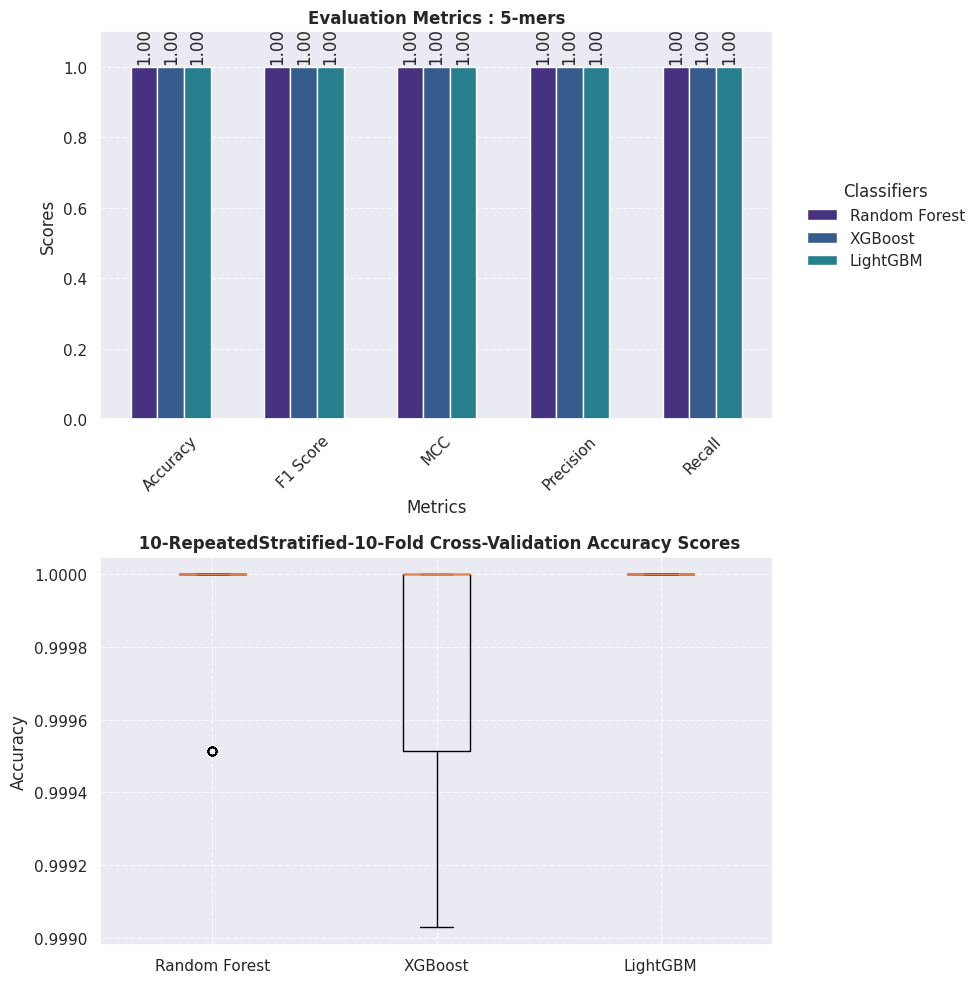

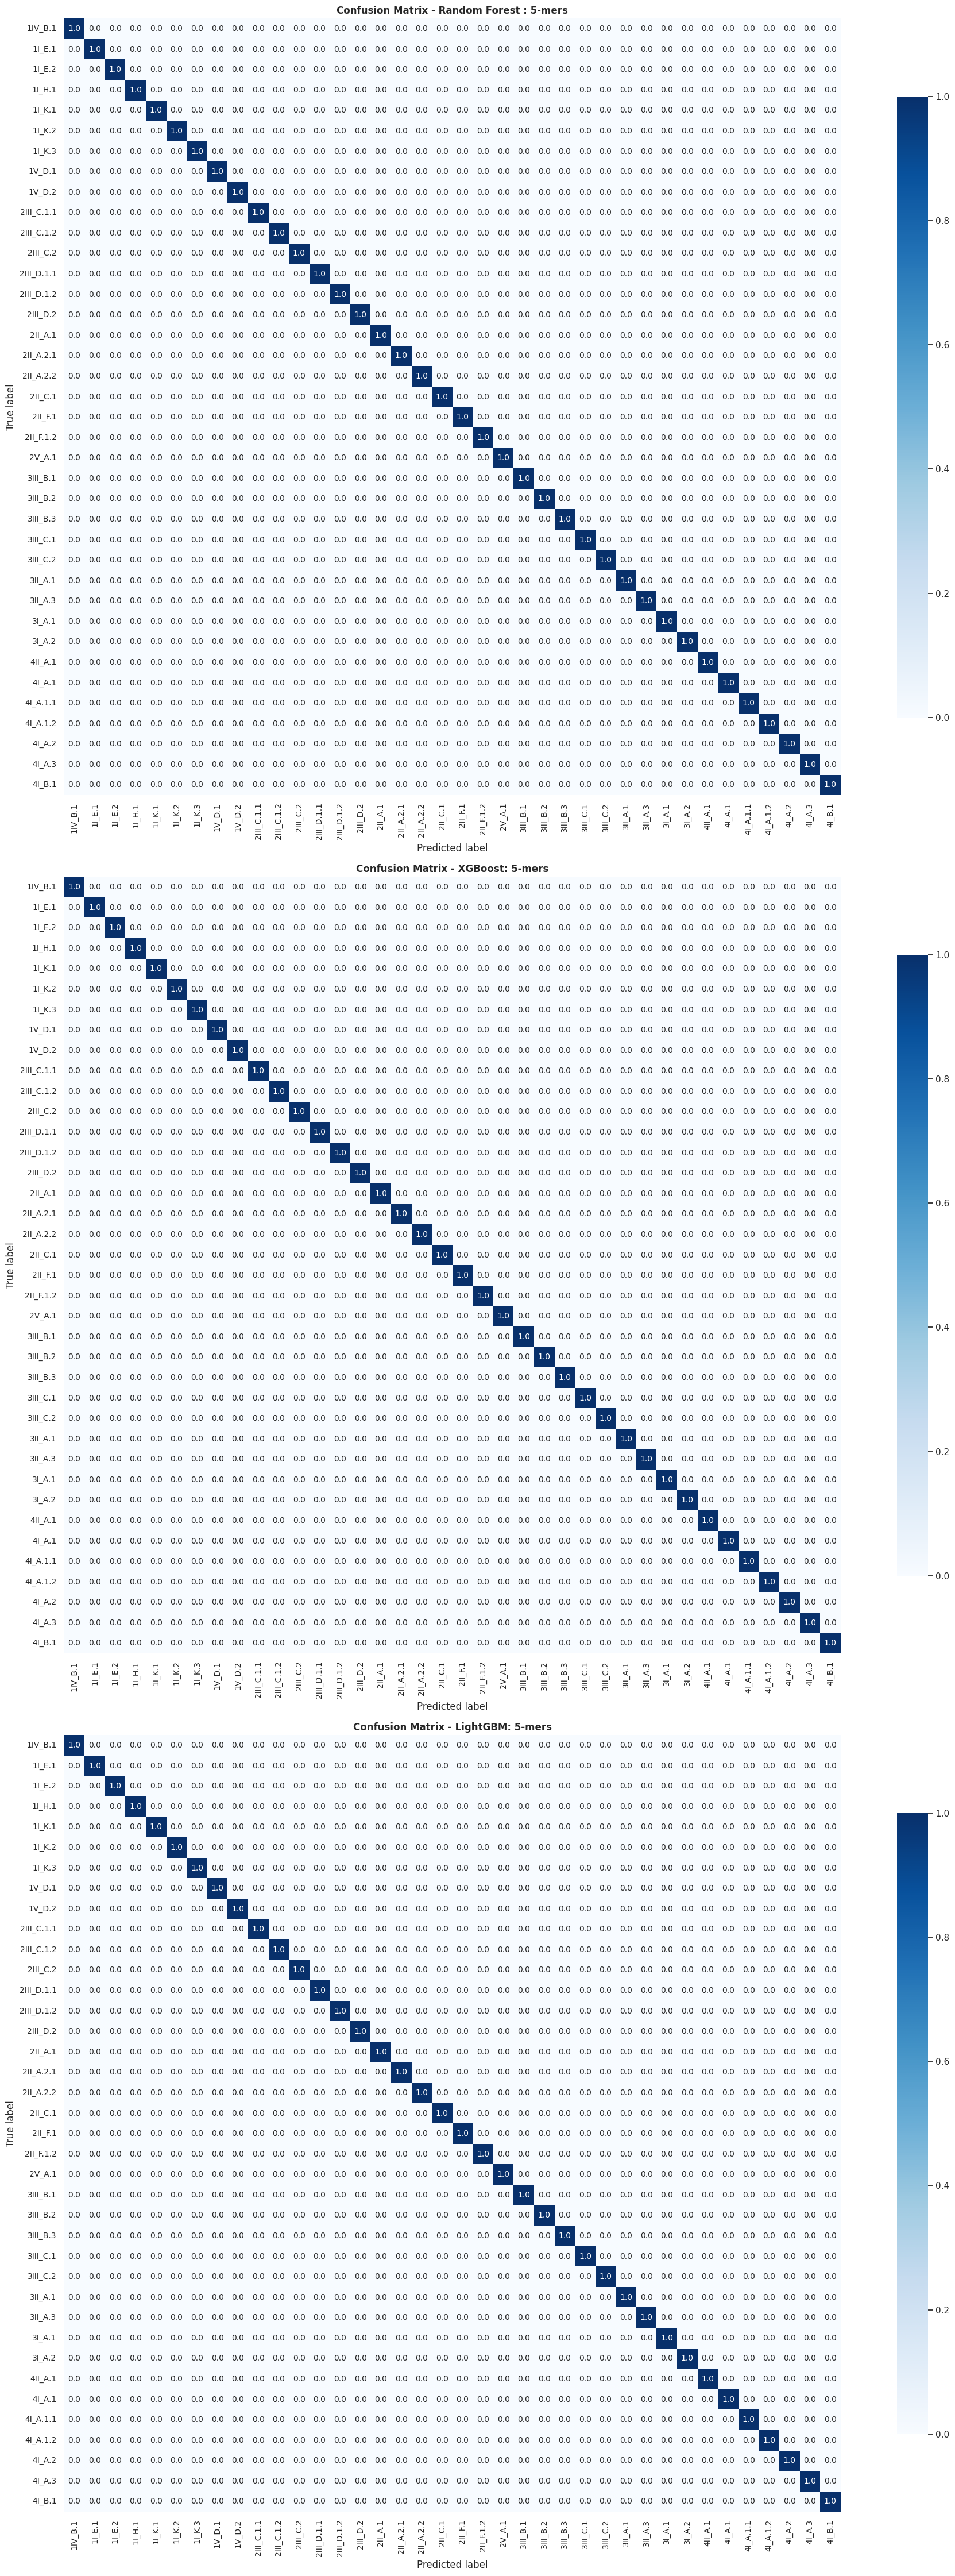

In [ ]:
k_mer = 5
train_evaluate_plot_kmodel(df, k=k_mer)

 **(B) Comparison between Flat and Hierarchical classifiers using 5-mers**

In [ ]:
#@title  B.2. Comparison between Flat and Hierarchical Classifiers while applying SMOTE
def train_evaluate_plot_combined_model_kmers(df,k, fontsize=15, figsize=(14, 6), title="Comparison between flat and hierarchical classifiers"):
    # Convert sequences to k-mers and apply CountVectorizer
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers'])
    # Convert to float32
    X_kmers = X_kmers.astype(np.float32)
    X = X_kmers

    # Make labels in a comfortable form for flat classifiers
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y_flat = df['Lineage_Label']

    print("Original class distribution :")
    print(Counter(y_flat))


    # Creating hierarchical labels
    df['Hierarchy'] = df['Taxonomic_Lineage'].apply(lambda x: x.split('_'))
    y_hierarchy = df['Hierarchy'].tolist()  # Ensure it's a list of lists


    # Train/test split
    X_train, X_test, y_train_flat, y_test_flat = train_test_split(X, y_flat, test_size=0.2, random_state=42)
    X_train_hier, X_test_hier, y_train_hier, y_test_hier = train_test_split(X, y_hierarchy, test_size=0.2, random_state=42)

    ### Apply SMOTE for flat classifiers
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_flat_resampled = smote.fit_resample(X_train, y_train_flat)

    # Print resampled class distribution
    print("\nResampled class distribution : ")
    print(Counter(y_train_flat_resampled))

    # Flat Classifiers
    flat_classifiers = {
        'Flat RF': RandomForestClassifier(n_estimators=234,max_depth=19,min_samples_split=17,min_samples_leaf=16,
                                          bootstrap=True,criterion='gini', n_jobs=-1, random_state=42),

        'Flat XGB': XGBClassifier(max_depth=14,learning_rate=0.0041,n_estimators=345,min_child_weight=1,subsample=0.9751,
                                  colsample_bytree=0.8915, n_jobs=-1,random_state=42),

        'Flat LGBM': lgb.LGBMClassifier(learning_rate=0.034,n_estimators=458, max_depth=0,num_leaves=247,feature_fraction=0.6218,
                                        bagging_fraction=0.8951,bagging_freq=3,min_child_samples=8, lambda_l1= 7.5168e-06,
                                        lambda_l2=0.0039,objective='multiclass',verbose=-1, n_jobs=-1,random_state=42)

    }

    # Hierarchical Classifiers
    rf_classifier =  RandomForestClassifier(n_estimators=234,max_depth=19,min_samples_split=17,min_samples_leaf=16,bootstrap=True,
                      criterion='gini', n_jobs=-1, random_state=42)
    hierarchical_classifiers = {
        'LCPN RF': LocalClassifierPerParentNode(local_classifier=rf_classifier),
        'LCL RF': LocalClassifierPerLevel(local_classifier=rf_classifier),
        'LCN RF': LocalClassifierPerNode(local_classifier=rf_classifier)
    }

    # Fit hierarchical classifiers
    for clf in hierarchical_classifiers.values():
        clf.fit(X_train_hier, y_train_hier)

    # Predict hierarchical classifiers
    predictions_hier = {name: clf.predict(X_test_hier) for name, clf in hierarchical_classifiers.items()}

    # Calculate hierarchical metrics
    hierarchical_metrics = {
        'Accuracy': [0, 0, 0],
        'MCC': [0, 0, 0],
        'Precision': [],
        'Recall': [],
        'F1 Score': []
    }

    for name, preds in predictions_hier.items():
        hR = hm.recall(y_test_hier, preds)
        hP = hm.precision(y_test_hier, preds)
        hF = hm.f1(y_test_hier, preds)
        hierarchical_metrics['Precision'].append(hP)
        hierarchical_metrics['Recall'].append(hR)
        hierarchical_metrics['F1 Score'].append(hF)

    # Collect flat classifier scores
    flat_metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    flat_scores = {name: [] for name in flat_metrics.keys()}
    for clf_name, clf in flat_classifiers.items():
        clf.fit(X_train_resampled, y_train_flat_resampled)
        y_pred = clf.predict(X_test)
        for metric_name, metric in flat_metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred, average='macro', zero_division=0))
            else:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred))

    # Plotting
    sns.set_theme()
    fig, ax = plt.subplots(figsize=figsize)

    bar_width = 0.1
    metrics = ['Accuracy', 'F1 Score', 'MCC', 'Precision', 'Recall']
    n_metrics = len(metrics)
    n_classifiers = len(flat_classifiers) + len(hierarchical_classifiers)

    index = np.arange(n_metrics)

    # Plot all classifiers
    all_classifiers = list(flat_classifiers.keys()) + list(hierarchical_classifiers.keys())
    all_scores = {metric: flat_scores[metric] + hierarchical_metrics[metric] for metric in metrics}

    colors = sns.palettes.mpl_palette('viridis', n_colors=n_classifiers)

    for i, clf_name in enumerate(all_classifiers):
        ax.bar(index + i * bar_width, [all_scores[metric][i] for metric in metrics],
               bar_width, label=clf_name, color=colors[i])

    # Set labels and title
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Scores')
    ax.set_xticks(index + bar_width * (n_classifiers / 2))
    ax.set_xticklabels(metrics, rotation=0, ha='right')
    ax.legend(title="Classifiers", bbox_to_anchor=(1.05, 0.7), loc="upper left", frameon=False)
    ax.set_title(title, fontsize=12,fontweight='bold')

    # Add text annotations for scores
    for i, clf_name in enumerate(all_classifiers):
        for j, metric in enumerate(metrics):
          # if metric is 0, don't print it:
            if all_scores[metric][i] == 0:
                continue
            ax.text(j + i * bar_width, all_scores[metric][i] + 0.02, f'{all_scores[metric][i]:.2f}', ha='center', rotation=90)

    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.grid(linestyle="--", alpha=0.7)
    # Save figure as a PDF
    plt.savefig(f"/content/5mers_comparison_Metrics_flat_hierarchical.pdf")
    plt.show()

k = 5
Original class distribution :
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution : 
Counter({19: 544, 4: 544, 7: 544, 8: 544, 20: 544, 24: 544, 28: 544, 1: 544, 14: 544, 36: 544, 15: 544, 33: 544, 35: 544, 9: 544, 18: 544, 25: 544, 3: 544, 34: 544, 6: 544, 10: 544, 31: 544, 11: 544, 21: 544, 17: 544, 27: 544, 32: 544, 22: 544, 30: 544, 5: 544, 29: 544, 0: 544, 2: 544, 16: 544, 37: 544, 12: 544, 23: 544, 13: 544, 26: 544})


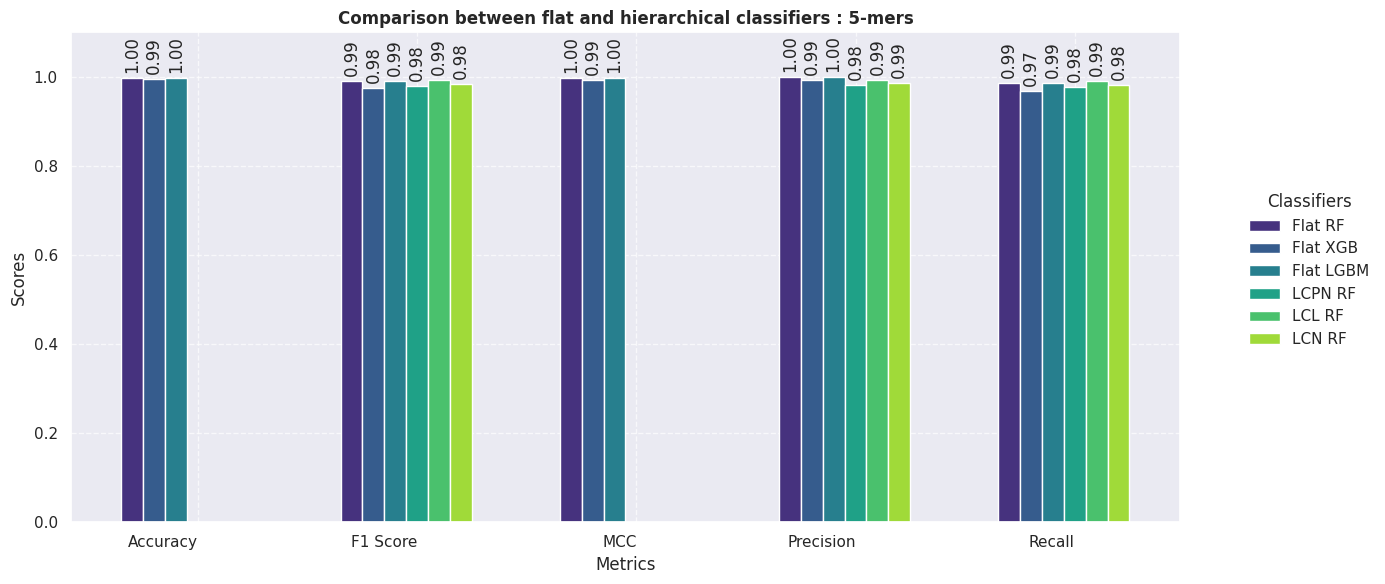

----------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# List of k-mers
k_mers = [5]
for k in k_mers:
  print(f"k = {k}")
  train_evaluate_plot_combined_model_kmers(df, k,title=f"Comparison between flat and hierarchical classifiers : {k}-mers")
  print(80*"--")

In [ ]:
#@title  B.3. Comparison between Flat and Hierarchical Classifiers without SMOTE
def train_evaluate_plot_combined_model_kmers(df,k, fontsize=12, figsize=(14, 6), title="Comparison between flat and hierarchical classifiers"):

    # Convert sequences to k-mers and apply CountVectorizer
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers'])
    # Convert to float32
    X_kmers = X_kmers.astype(np.float32)
    X = X_kmers

    # Make labels in a comfortable form for flat classifiers
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y_flat = df['Lineage_Label']

    # Creating hierarchical labels
    df['Hierarchy'] = df['Taxonomic_Lineage'].apply(lambda x: x.split('_'))
    y_hierarchy = df['Hierarchy'].tolist()  # Ensure it's a list of lists

    # Train/test split
    X_train, X_test, y_train_flat, y_test_flat = train_test_split(X, y_flat, test_size=0.2, random_state=42)
    X_train_hier, X_test_hier, y_train_hier, y_test_hier = train_test_split(X, y_hierarchy, test_size=0.2, random_state=42)

    # Flat Classifiers
    flat_classifiers = {
        'Flat RF': RandomForestClassifier(n_estimators=234,max_depth=19,min_samples_split=17,min_samples_leaf=16,bootstrap=True,criterion='gini', n_jobs=-1, random_state=42),
        'Flat XGB': XGBClassifier(max_depth=14,learning_rate=0.0041,n_estimators=345,min_child_weight=1,subsample=0.9751,colsample_bytree=0.8915, n_jobs=-1,random_state=42),
        'Flat LGBM': lgb.LGBMClassifier(learning_rate=0.034,n_estimators=458, max_depth=0,num_leaves=247,feature_fraction=0.6218,bagging_fraction=0.8951,
                                      bagging_freq=3,min_child_samples=8, lambda_l1= 7.5168e-06, lambda_l2=0.0039,objective='multiclass',verbose=-1, n_jobs=-1,random_state=42)
    }

    # Hierarchical Classifiers
    rf_classifier = RandomForestClassifier(n_estimators=234,max_depth=19,min_samples_split=17,min_samples_leaf=16,bootstrap=True,criterion='gini', n_jobs=-1, random_state=42)
    hierarchical_classifiers = {
        'LCPN RF': LocalClassifierPerParentNode(local_classifier=rf_classifier),
        'LCL RF': LocalClassifierPerLevel(local_classifier=rf_classifier),
        'LCN RF': LocalClassifierPerNode(local_classifier=rf_classifier)
    }

    # Fit hierarchical classifiers
    for clf in hierarchical_classifiers.values():
        clf.fit(X_train_hier, y_train_hier)

    # Predict hierarchical classifiers
    predictions_hier = {name: clf.predict(X_test_hier) for name, clf in hierarchical_classifiers.items()}

    # Calculate hierarchical metrics
    hierarchical_metrics = {
        'Accuracy': [0, 0, 0],
        'MCC': [0, 0, 0],
        'Precision': [],
        'Recall': [],
        'F1 Score': []
    }

    for name, preds in predictions_hier.items():
        hR = hm.recall(y_test_hier, preds)
        hP = hm.precision(y_test_hier, preds)
        hF = hm.f1(y_test_hier, preds)
        hierarchical_metrics['Precision'].append(hP)
        hierarchical_metrics['Recall'].append(hR)
        hierarchical_metrics['F1 Score'].append(hF)

    # Collect flat classifier scores
    flat_metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    flat_scores = {name: [] for name in flat_metrics.keys()}
    for clf_name, clf in flat_classifiers.items():
        clf.fit(X_train, y_train_flat)
        y_pred = clf.predict(X_test)
        for metric_name, metric in flat_metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred, average='macro', zero_division=0))
            else:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred))

    # Plotting
    sns.set_theme()
    fig, ax = plt.subplots(figsize=figsize)

    bar_width = 0.1
    metrics = ['Accuracy', 'F1 Score', 'MCC', 'Precision', 'Recall']
    n_metrics = len(metrics)
    n_classifiers = len(flat_classifiers) + len(hierarchical_classifiers)

    index = np.arange(n_metrics)

    # Plot all classifiers
    all_classifiers = list(flat_classifiers.keys()) + list(hierarchical_classifiers.keys())
    all_scores = {metric: flat_scores[metric] + hierarchical_metrics[metric] for metric in metrics}

    colors = sns.palettes.mpl_palette('Dark2', n_colors=n_classifiers)

    for i, clf_name in enumerate(all_classifiers):
        ax.bar(index + i * bar_width, [all_scores[metric][i] for metric in metrics],
               bar_width, label=clf_name, color=colors[i])

    # Set labels and title
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Scores')
    ax.set_xticks(index + bar_width * (n_classifiers / 2))
    ax.set_xticklabels(metrics, rotation=0, ha='right')
    ax.legend(title="Classifiers", bbox_to_anchor=(1.05, 0.5), loc="upper left", frameon=False)
    ax.set_title(title, fontsize=fontsize, fontweight='bold')

    # Add text annotations for scores
    for i, clf_name in enumerate(all_classifiers):
        for j, metric in enumerate(metrics):
          # if metric is 0, don't print it:
            if all_scores[metric][i] == 0:
                continue
            ax.text(j + i * bar_width, all_scores[metric][i] + 0.02, f'{all_scores[metric][i]:.2f}', ha='center', rotation=90)

    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.grid(linestyle="--", alpha=0.7)
    # Save figure as a PDF
    plt.savefig(f"/content/5mers_comparison_Metrics_no_smote.pdf")
    plt.show()

k = 5


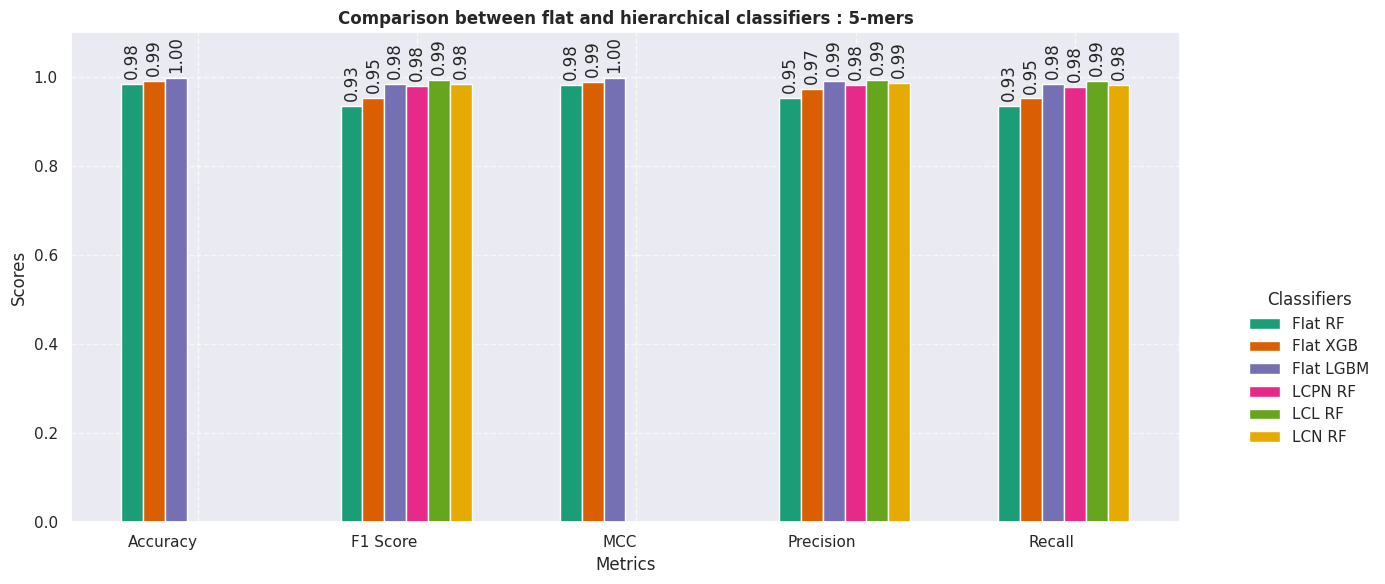

----------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# List of k-mers
k_mers = [5]
for k in k_mers:
  print(f"k = {k}")
  train_evaluate_plot_combined_model_kmers(df, k,title=f"Comparison between flat and hierarchical classifiers : {k}-mers")
  print(80*"--")

In [ ]:
# @title B.4.  Feature importance using 5-mers for Random Forest
def feature_importance_rf_kmer(df, k=5):
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x,k)))

    # Step 2: Use CountVectorizer to convert k-mers into a bag-of-words model
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers']).toarray()  # Features as k-mers
    y = df['Lineage']  # Target variable

    X_train, X_test, y_train, y_test = train_test_split(X_kmers, y, test_size=0.2,stratify=y, random_state=42)

    # Step 3: Train a Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=234,
        max_depth=19,
        min_samples_split=17,
        min_samples_leaf=16,
        bootstrap=True,
        criterion='gini',
        n_jobs=-1,
        random_state=42)

    rf_model.fit(X_train, y_train)

    # Step 4: Extract and visualize feature importance (for k-mers)
    importances = rf_model.feature_importances_
    feature_names = vectorizer.get_feature_names_out()

    # Create a DataFrame for visualization
    feature_importance_df = pd.DataFrame({
        'k-mer': feature_names,
        'Importance': importances
    })

    # Sort and plot the most important k-mers
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Plot the top 20 most important k-mers
    plt.figure(figsize=(15, 15))
    sns.barplot(x='k-mer', y='Importance', data=feature_importance_df.head(20),color='teal',alpha=1.0)
    plt.title(f'Top 20 Important {k}-mers in Random Forest',fontweight='bold')
    plt.xlabel(f'{k}-mer')
    plt.ylabel('Importance Score')
    plt.grid(linestyle="--", alpha=1.0)
    plt.savefig("/content/kmer_5_rf_feature_importance.pdf")
    plt.show()

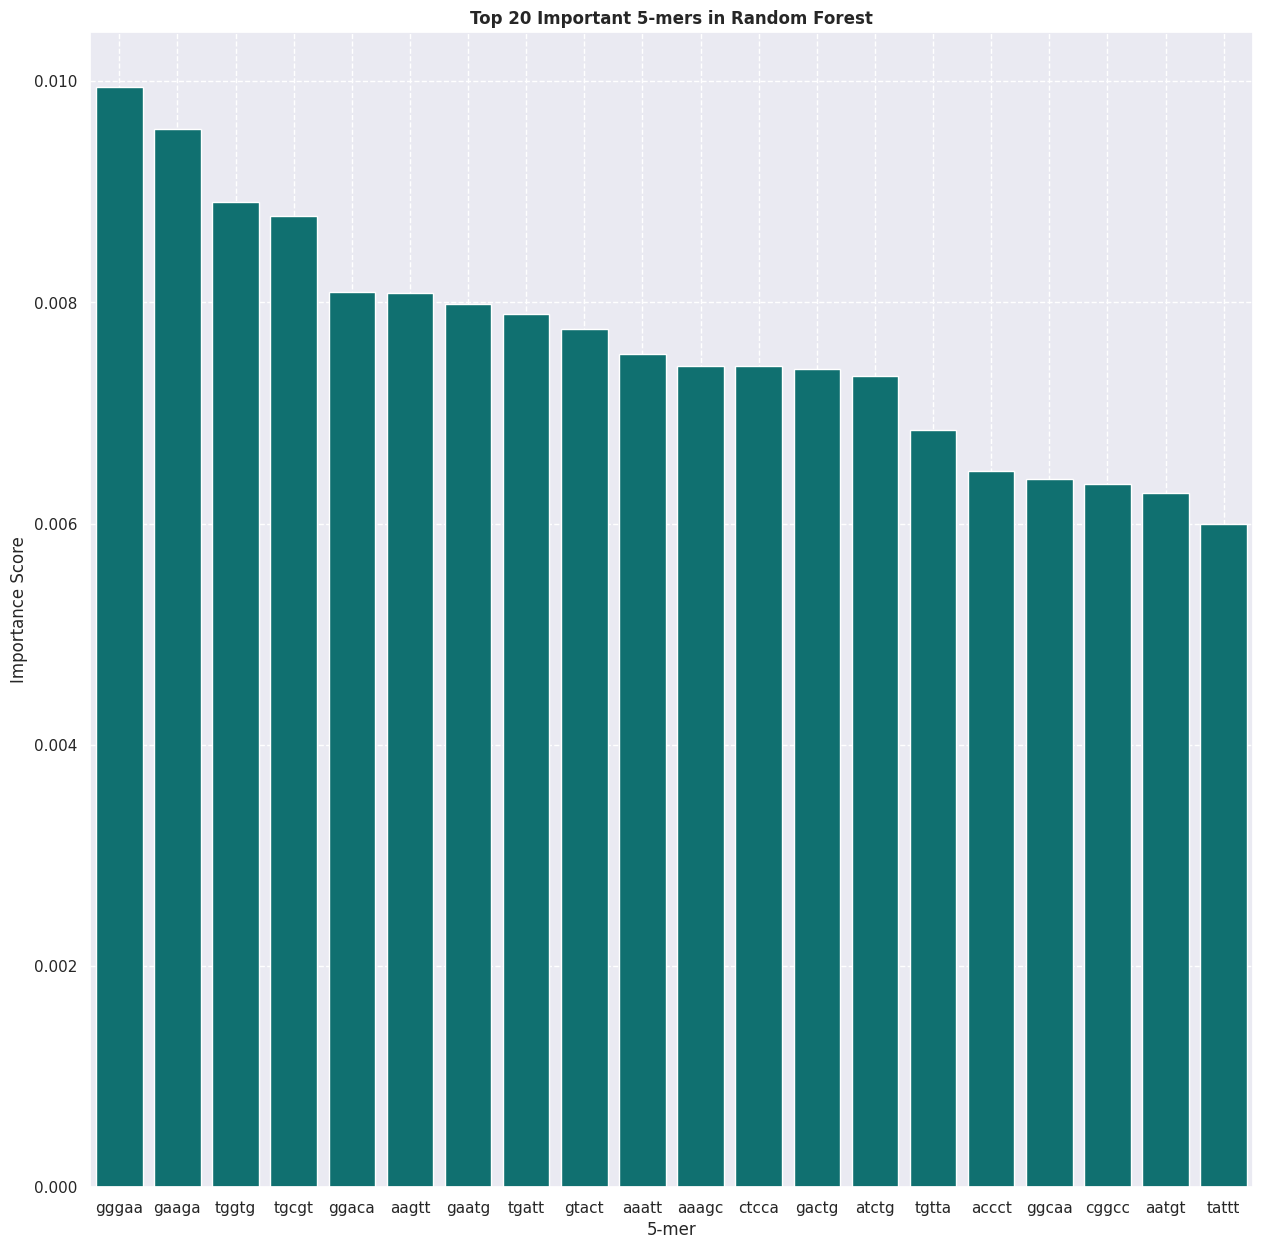

In [ ]:
feature_importance_rf_kmer(df)

# `II.2.2. FCGR`

**(A). Hierachical Classification**

In [ ]:
#@title A.1. Apply 32-FCGR as Feature extraction Technique plus SMOTE for flat classifiers
resolution_=32
# Convert sequences to a 2D CGR-based feature extraction
X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

# Convert to float32
X_fcgr = X_fcgr.astype(np.float32)
X = X_fcgr

# Encode labels for flat classifier
label_encoder = LabelEncoder()
df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
y_flat = df['Lineage_Label']

print("Original class distribution:")
print(Counter(y_flat))

# Creating hierarchical labels
df['Hierarchy'] = df['Taxonomic_Lineage'].apply(lambda x: x.split('_'))
y_hierarchy = df['Hierarchy'].tolist()  # Ensure it's a list of lists

# Train/test split
X_train, X_test, y_train_flat, y_test_flat = train_test_split(X, y_flat, test_size=0.2, random_state=42)
X_train_hier, X_test_hier, y_train_hier, y_test_hier = train_test_split(X, y_hierarchy, test_size=0.2, random_state=42)

# Apply SMOTE for flat classifiers
smote = SMOTE(random_state=42)
X_train_resampled, y_train_flat_resampled = smote.fit_resample(X_train, y_train_flat)

print("\nResampled class distribution:")
print(Counter(y_train_flat_resampled))

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({19: 544, 4: 544, 7: 544, 8: 544, 20: 544, 24: 544, 28: 544, 1: 544, 14: 544, 36: 544, 15: 544, 33: 544, 35: 544, 9: 544, 18: 544, 25: 544, 3: 544, 34: 544, 6: 544, 10: 544, 31: 544, 11: 544, 21: 544, 17: 544, 27: 544, 32: 544, 22: 544, 30: 544, 5: 544, 29: 544, 0: 544, 2: 544, 16: 544, 37: 544, 12: 544, 23: 544, 13: 544, 26: 544})


In [ ]:
#@title A.2. Training

# Flat Classifiers
flat_classifiers = {
    'Flat RF': RandomForestClassifier(n_estimators=77,
                                      max_depth=12,
                                      min_samples_split=15,
                                      min_samples_leaf=5,
                                      bootstrap=True,
                                      criterion='entropy',
                                      n_jobs=-1,
                                      random_state=42),

}

# Hierarchical Classifiers
rf_classifier = RandomForestClassifier(n_estimators=77,
                                      max_depth=12,
                                      min_samples_split=15,
                                      min_samples_leaf=5,
                                      bootstrap=True,
                                      criterion='entropy',
                                      n_jobs=-1,
                                      random_state=42)
hierarchical_classifiers = {
    'LCPN RF': LocalClassifierPerParentNode(local_classifier=rf_classifier),
    'LCL RF': LocalClassifierPerLevel(local_classifier=rf_classifier),
    'LCN RF': LocalClassifierPerNode(local_classifier=rf_classifier)
}

# Fit hierarchical classifiers
for clf in hierarchical_classifiers.values():
    clf.fit(X_train_hier, y_train_hier)

# Predict hierarchical classifiers
predictions_hier = {name: clf.predict(X_test_hier) for name, clf in hierarchical_classifiers.items()}

# Calculate hierarchical metrics
hierarchical_metrics = {
    'Accuracy': [0, 0, 0],
    'MCC': [0, 0, 0],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

for name, preds in predictions_hier.items():
    hR = hm.recall(y_test_hier, preds)
    hP = hm.precision(y_test_hier, preds)
    hF = hm.f1(y_test_hier, preds)
    hierarchical_metrics['Precision'].append(hP)
    hierarchical_metrics['Recall'].append(hR)
    hierarchical_metrics['F1 Score'].append(hF)

# Collect flat classifier scores
flat_metrics = {
    'Accuracy': accuracy_score,
    'F1 Score': f1_score,
    'MCC': matthews_corrcoef,
    'Precision': precision_score,
    'Recall': recall_score
}

flat_scores = {name: [] for name in flat_metrics.keys()}
for clf_name, clf in flat_classifiers.items():
    clf.fit(X_train_resampled, y_train_flat_resampled)
    y_pred = clf.predict(X_test)
    for metric_name, metric in flat_metrics.items():
        if metric_name in ['F1 Score', 'Precision', 'Recall']:
            flat_scores[metric_name].append(metric(y_test_flat, y_pred, average='macro', zero_division=0))
        else:
            flat_scores[metric_name].append(metric(y_test_flat, y_pred))

In [ ]:
#@title A.3. Define levels

# Classifier names for labeling
classifier_names = list(hierarchical_classifiers.keys())

# Define metrics and levels for labels
metrics = ['Precision', 'Recall', 'F1 Score']
levels = ['Serotype', 'Genotype', 'Major Lineage', 'Minor Lineage']
n_levels = len(levels)

# Initialize dictionary to hold hierarchical metrics per level
hierarchical_metrics_per_level = {level: {'Precision': [], 'Recall': [], 'F1 Score': []} for level in levels}

# Calculate hierarchical metrics for each classifier at each level
for name, preds in predictions_hier.items():
    for i, level in enumerate(levels):
        # Extract true and predicted labels at the current level
        true_level_labels = [true[i] if i < len(true) else None for true in y_test_hier]
        pred_level_labels = [pred[i] if i < len(pred) else None for pred in preds]

        # Calculate hierarchical metrics at this level
        hR = hm.recall(true_level_labels, pred_level_labels)
        hP = hm.precision(true_level_labels, pred_level_labels)
        hF = hm.f1(true_level_labels, pred_level_labels)

        # Store metrics
        hierarchical_metrics_per_level[level]['Precision'].append(hP)
        hierarchical_metrics_per_level[level]['Recall'].append(hR)
        hierarchical_metrics_per_level[level]['F1 Score'].append(hF)

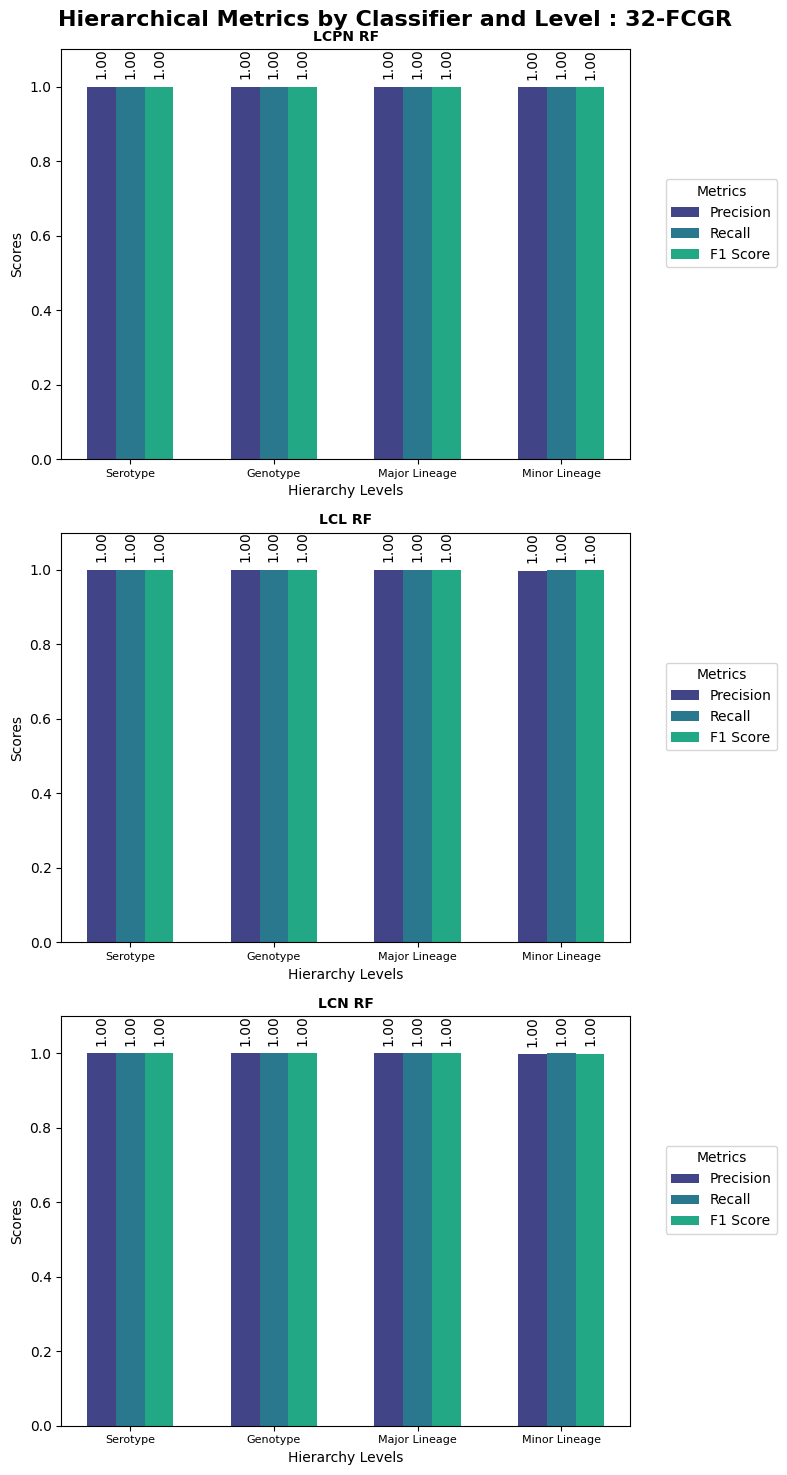

In [ ]:
#@title A.4. Display plots

# Set up the plot with subplots for each classifier
fig, axes = plt.subplots(len(classifier_names), 1, figsize=(8, 15), sharex=False, sharey=False)
fig.suptitle(f"Hierarchical Metrics by Classifier and Level : {resolution_}-FCGR", fontsize=16, fontweight='bold')
bar_width = 0.2
colors = sns.color_palette("viridis", n_levels)

# Create subplots for each hierarchical classifier
for idx, (ax, clf_name) in enumerate(zip(axes, classifier_names)):
    # Plot each metric as grouped bars for each level
    for metric_idx, metric in enumerate(metrics):
        # Extract metric values for the current classifier and metric
        values = [hierarchical_metrics_per_level[level][metric][idx] for level in levels]

        # Set bar positions
        bar_positions = np.arange(n_levels) + (metric_idx * bar_width)

        # Plot bars with annotations
        bars = ax.bar(bar_positions, values, bar_width, label=metric, color=colors[metric_idx])

        # Annotate values on top of each bar
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # Center of bar
                bar.get_height() + 0.02,            # Slightly above bar
                f"{value:.2f}",                     # Display value
                ha="center", va="bottom", rotation=90, fontsize=10)

    # Formatting each subplot
    ax.set_title(f"{clf_name}", fontsize=10, fontweight='bold')
    ax.set_xticks(np.arange(n_levels) + bar_width)
    ax.set_xticklabels(levels,fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Hierarchy Levels', fontsize=10)
    ax.set_ylabel('Scores', fontsize=10)
    ax.legend(title="Metrics", bbox_to_anchor=(1.05, 0.7), loc="upper left", fontsize=10)

# Final adjustments
plt.tight_layout()
plt.show()

**(B) 10x Repeated Stratified 10-Fold Cross-Validation with 32-FCGR and SMOTE for Flat Classifiers**

In [ ]:
# @title B.1. 10-Repeated Stratified 10-Fold-Cross Validation
def train_evaluate_plot_fcgr_model(df, resolution_=32, fontsize=15):

    # Convert sequences to a 2D CGR-based feature extraction
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

    # Convert to float32
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    # Make labels in a comfortable form
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))


    # Classifiers
    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=77,max_depth=12,min_samples_split=15,
                                                min_samples_leaf=5,bootstrap=True,criterion='entropy', n_jobs=-1, random_state=42),

        'XGBoost': XGBClassifier(max_depth=15,learning_rate=0.0271,n_estimators=253,min_child_weight=9,
                                 subsample=0.6411,colsample_bytree=0.5212, n_jobs=-1,random_state=42),

        'LightGBM': lgb.LGBMClassifier(learning_rate=0.0870,n_estimators=836, max_depth=1,num_leaves=26,
                                       feature_fraction=0.8267 ,bagging_fraction=0.5361,
                                      bagging_freq=1,min_child_samples=25, lambda_l1= 0.0008, lambda_l2=1.0356e-06,objective='multiclass',
                                       verbose=-1, n_jobs=-1,random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)
    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifiers", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {resolution_}-FCGR", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.2)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/{clf_name}_{resolution_}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, axs = plt.subplots(3, 1, figsize=(20, 45))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred,normalize='true')
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True, ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 1.0})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/{clf_name}_{resolution_}_ConfusionMatrix.pdf")


    # Plot confusion matrices
    class_names = label_encoder.classes_

    # Random forest
    plot_confusion_matrix(axs[0], y_test, predictions['Random Forest'], class_names, f'Confusion Matrix - Random Forest : {resolution_}-FCGR')
    # XGBoost
    plot_confusion_matrix(axs[1], y_test, predictions['XGBoost'], class_names, f'Confusion Matrix - XGBoost: {resolution_}-FCGR')
    # LightGBM
    plot_confusion_matrix(axs[2], y_test, predictions['LightGBM'], class_names, f'Confusion Matrix - LightGBM: {resolution_}-FCGR')

    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})


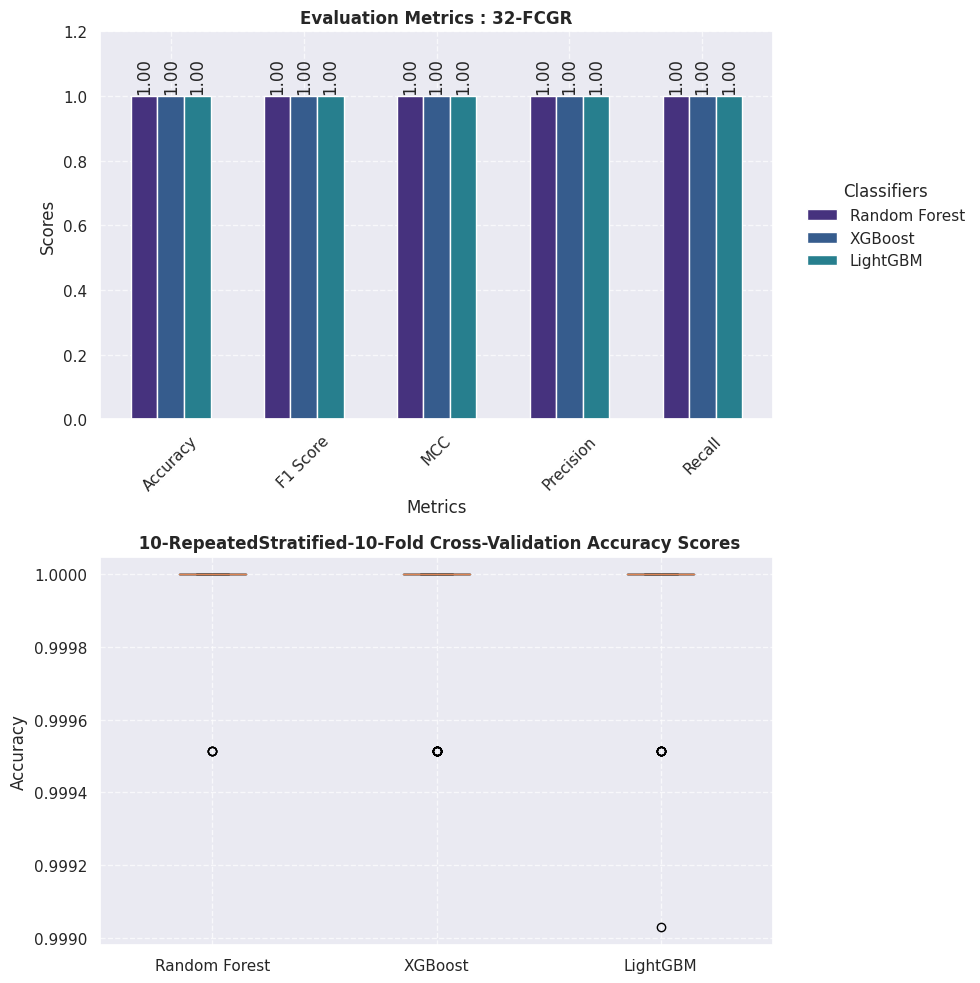

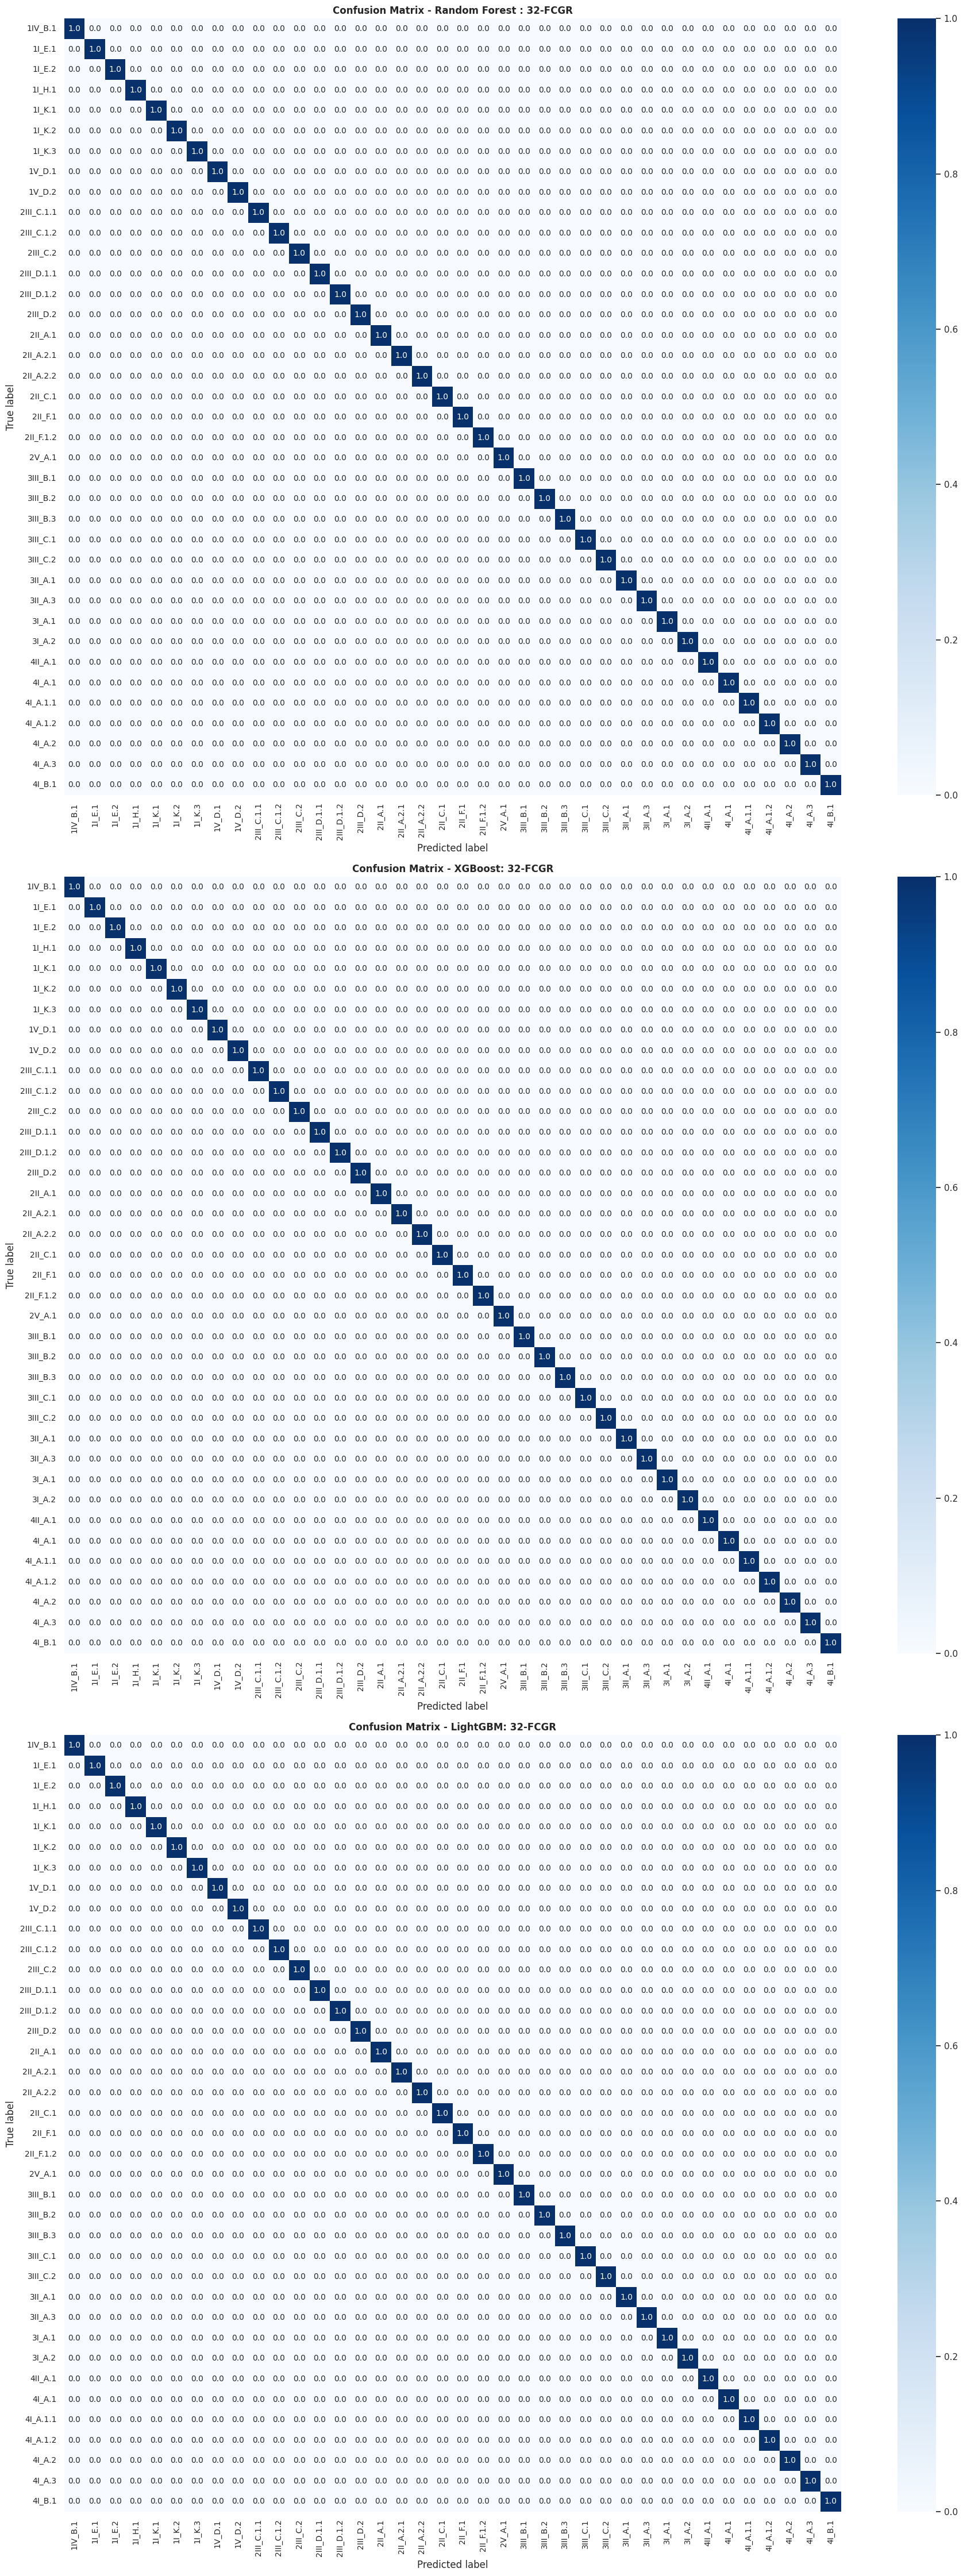

In [ ]:
fcgr_value = 32
train_evaluate_plot_fcgr_model(df, resolution_=fcgr_value)

 **(B) Comparison between Flat and Hierarchical classifiers using 32-FCGR**

In [ ]:
# @title B.2. Comparison between Flat and Hierarchical Classifiers while applying SMOTE
def train_evaluate_plot_combined_model_fcgr(df,resolution_, fontsize=15, figsize=(14, 6), title="Comparison between flat and hierarchical classifiers"):

    # Convert sequences to a 2D CGR-based feature extraction
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

    # Convert to float32
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    # Make labels in a comfortable form for flat classifiers
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y_flat = df['Lineage_Label']

    print("Original class distribution :")
    print(Counter(y_flat))


        # Creating hierarchical labels
    df['Hierarchy'] = df['Taxonomic_Lineage'].apply(lambda x: x.split('_'))
    y_hierarchy = df['Hierarchy'].tolist()  # Ensure it's a list of lists



    # Train/test split
    X_train, X_test, y_train_flat, y_test_flat = train_test_split(X, y_flat, test_size=0.2,stratify=y_flat, random_state=42)
    X_train_hier, X_test_hier, y_train_hier, y_test_hier = train_test_split(X, y_hierarchy, test_size=0.2,stratify=y_hierarchy, random_state=42)

    ### Apply SMOTE for flat classifiers
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_flat_resampled = smote.fit_resample(X_train, y_train_flat)

    # Print resampled class distribution
    print("\nResampled class distribution : ")
    print(Counter(y_train_flat_resampled))

    # Flat Classifiers
    flat_classifiers = {
        'Flat RF': RandomForestClassifier(n_estimators=77,max_depth=12,min_samples_split=15,
                                                min_samples_leaf=5,bootstrap=True,criterion='entropy', n_jobs=-1, random_state=42),

        'Flat XGB': XGBClassifier(max_depth=15,learning_rate=0.0271,n_estimators=253,min_child_weight=9,
                                 subsample=0.6411,colsample_bytree=0.5212, n_jobs=-1,random_state=42),

        'Flat LGBM': lgb.LGBMClassifier(learning_rate=0.0870,n_estimators=836, max_depth=1,num_leaves=26,
                                       feature_fraction=0.8267 ,bagging_fraction=0.5361,
                                      bagging_freq=1,min_child_samples=25, lambda_l1= 0.0008, lambda_l2=1.0356e-06,objective='multiclass',
                                       verbose=-1, n_jobs=-1,random_state=42)
    }


    # Hierarchical Classifiers
    rf_classifier = RandomForestClassifier(n_estimators=77,max_depth=12,min_samples_split=15,
                    min_samples_leaf=5,bootstrap=True,criterion='entropy', n_jobs=-1, random_state=42)

    hierarchical_classifiers = {
        'LCPN RF': LocalClassifierPerParentNode(local_classifier=rf_classifier),
        'LCL RF': LocalClassifierPerLevel(local_classifier=rf_classifier),
        'LCN RF': LocalClassifierPerNode(local_classifier=rf_classifier)
    }

    # Fit hierarchical classifiers
    for clf in hierarchical_classifiers.values():
        clf.fit(X_train_hier, y_train_hier)

    # Predict hierarchical classifiers
    predictions_hier = {name: clf.predict(X_test_hier) for name, clf in hierarchical_classifiers.items()}

    # Calculate hierarchical metrics
    hierarchical_metrics = {
        'Accuracy': [0, 0, 0],
        'MCC': [0, 0, 0],
        'Precision': [],
        'Recall': [],
        'F1 Score': []
    }

    for name, preds in predictions_hier.items():
        hR = hm.recall(y_test_hier, preds)
        hP = hm.precision(y_test_hier, preds)
        hF = hm.f1(y_test_hier, preds)
        hierarchical_metrics['Precision'].append(hP)
        hierarchical_metrics['Recall'].append(hR)
        hierarchical_metrics['F1 Score'].append(hF)

    # Collect flat classifier scores
    flat_metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    flat_scores = {name: [] for name in flat_metrics.keys()}
    for clf_name, clf in flat_classifiers.items():
        clf.fit(X_train_resampled, y_train_flat_resampled)
        y_pred = clf.predict(X_test)
        for metric_name, metric in flat_metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred, average='macro', zero_division=0))
            else:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred))

    # Plotting
    sns.set_theme()
    fig, ax = plt.subplots(figsize=figsize)

    bar_width = 0.1
    metrics = ['Accuracy', 'F1 Score', 'MCC', 'Precision', 'Recall']
    n_metrics = len(metrics)
    n_classifiers = len(flat_classifiers) + len(hierarchical_classifiers)

    index = np.arange(n_metrics)

    # Plot all classifiers
    all_classifiers = list(flat_classifiers.keys()) + list(hierarchical_classifiers.keys())
    all_scores = {metric: flat_scores[metric] + hierarchical_metrics[metric] for metric in metrics}

    colors = sns.palettes.mpl_palette('viridis', n_colors=n_classifiers)

    for i, clf_name in enumerate(all_classifiers):
        ax.bar(index + i * bar_width, [all_scores[metric][i] for metric in metrics],
               bar_width, label=clf_name, color=colors[i])

    # Set labels and title
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Scores')
    ax.set_xticks(index + bar_width * (n_classifiers / 2))
    ax.set_xticklabels(metrics, rotation=0, ha='right')
    ax.legend(title="Classifiers", bbox_to_anchor=(1.05, 0.7), loc="upper left", frameon=False)
    ax.set_title(title, fontsize=12,fontweight='bold')

    # Add text annotations for scores
    for i, clf_name in enumerate(all_classifiers):
        for j, metric in enumerate(metrics):
          # if metric is 0, don't print it:
            if all_scores[metric][i] == 0:
                continue
            ax.text(j + i * bar_width, all_scores[metric][i] + 0.02, f'{all_scores[metric][i]:.2f}', ha='center', rotation=90)

    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.grid(linestyle="--", alpha=0.7)
    # Save figure as a PDF
    plt.savefig(f"/content/fcgr_32__comparison_flat_hierarchical.pdf")
    plt.show()

Resolution = 32
Original class distribution :
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution : 
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})


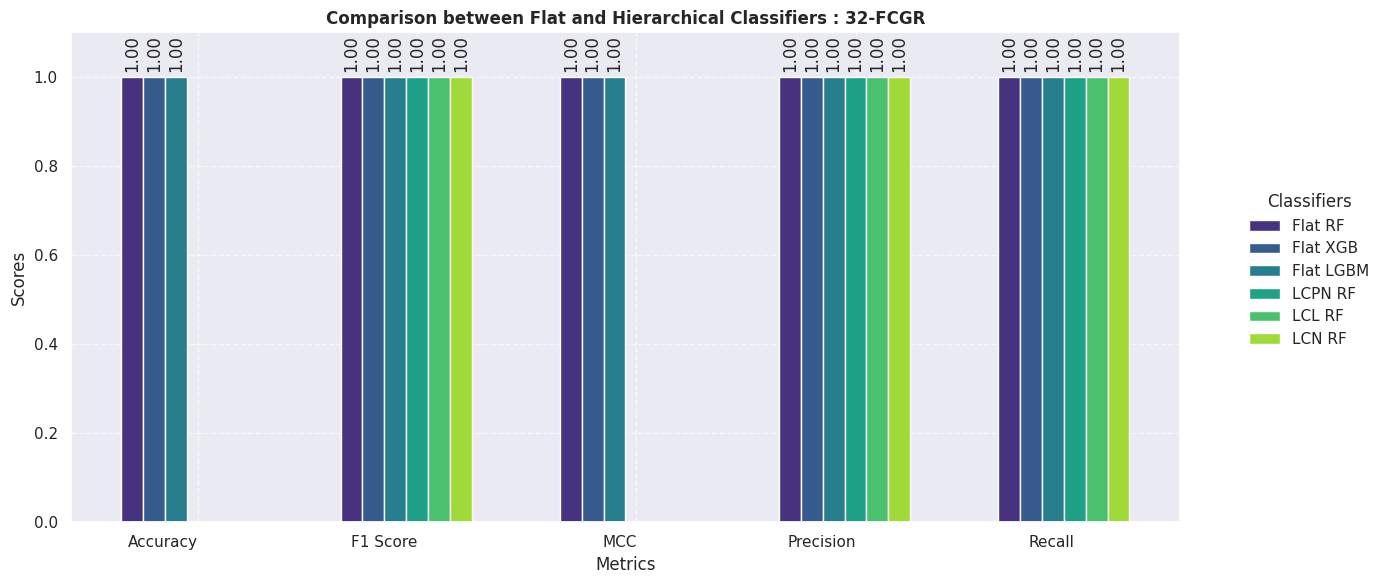

----------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# List of fcgr_values
fcgr_values = [32]
for reso in fcgr_values:
  print(f"Resolution = {reso}")
  train_evaluate_plot_combined_model_fcgr(df, reso,title=f"Comparison between Flat and Hierarchical Classifiers : {reso}-FCGR")
  print(80*"--")

In [ ]:
#@title  B.3. Comparison between Flat and Hierarchical Classifiers without SMOTE
def train_evaluate_plot_combined_model_fcgr(df,resolution_=32, fontsize=12, figsize=(14, 6), title="Comparison between flat and hierarchical classifiers"):

    # Convert sequences to a 2D CGR-based feature extraction
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

    # Convert to float32
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    # Make labels in a comfortable form for flat classifiers
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y_flat = df['Lineage_Label']

    # Creating hierarchical labels
    df['Hierarchy'] = df['Taxonomic_Lineage'].apply(lambda x: x.split('_'))
    y_hierarchy = df['Hierarchy'].tolist()  # Ensure it's a list of lists

    # Train/test split
    X_train, X_test, y_train_flat, y_test_flat = train_test_split(X, y_flat, test_size=0.2,stratify=y_flat, random_state=42)
    X_train_hier, X_test_hier, y_train_hier, y_test_hier = train_test_split(X, y_hierarchy, test_size=0.2,stratify=y_hierarchy, random_state=42)

    # Flat Classifiers
    flat_classifiers = {
        'Flat RF': RandomForestClassifier(n_estimators=77,max_depth=12,min_samples_split=15,
                                                min_samples_leaf=5,bootstrap=True,criterion='entropy', n_jobs=-1, random_state=42),

        'Flat XGB': XGBClassifier(max_depth=15,learning_rate=0.0271,n_estimators=253,min_child_weight=9,
                                 subsample=0.6411,colsample_bytree=0.5212, n_jobs=-1,random_state=42),

        'Flat LGBM': lgb.LGBMClassifier(learning_rate=0.0870,n_estimators=836, max_depth=1,num_leaves=26,
                                       feature_fraction=0.8267 ,bagging_fraction=0.5361,
                                      bagging_freq=1,min_child_samples=25, lambda_l1= 0.0008, lambda_l2=1.0356e-06,objective='multiclass',
                                       verbose=-1, n_jobs=-1,random_state=42)
    }


    # Hierarchical Classifiers
    rf_classifier = RandomForestClassifier(n_estimators=77,max_depth=12,min_samples_split=15,
                    min_samples_leaf=5,bootstrap=True,criterion='entropy', n_jobs=-1, random_state=42)
    hierarchical_classifiers = {
        'LCPN RF': LocalClassifierPerParentNode(local_classifier=rf_classifier),
        'LCL RF': LocalClassifierPerLevel(local_classifier=rf_classifier),
        'LCN RF': LocalClassifierPerNode(local_classifier=rf_classifier)
    }

    # Fit hierarchical classifiers
    for clf in hierarchical_classifiers.values():
        clf.fit(X_train_hier, y_train_hier)

    # Predict hierarchical classifiers
    predictions_hier = {name: clf.predict(X_test_hier) for name, clf in hierarchical_classifiers.items()}

    # Calculate hierarchical metrics
    hierarchical_metrics = {
        'Accuracy': [0, 0, 0],
        'MCC': [0, 0, 0],
        'Precision': [],
        'Recall': [],
        'F1 Score': []
    }

    for name, preds in predictions_hier.items():
        hR = hm.recall(y_test_hier, preds)
        hP = hm.precision(y_test_hier, preds)
        hF = hm.f1(y_test_hier, preds)
        hierarchical_metrics['Precision'].append(hP)
        hierarchical_metrics['Recall'].append(hR)
        hierarchical_metrics['F1 Score'].append(hF)

    # Collect flat classifier scores
    flat_metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    flat_scores = {name: [] for name in flat_metrics.keys()}
    for clf_name, clf in flat_classifiers.items():
        clf.fit(X_train, y_train_flat)
        y_pred = clf.predict(X_test)
        for metric_name, metric in flat_metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred, average='macro', zero_division=0))
            else:
                flat_scores[metric_name].append(metric(y_test_flat, y_pred))

    # Plotting
    sns.set_theme()
    fig, ax = plt.subplots(figsize=figsize)

    bar_width = 0.1
    metrics = ['Accuracy', 'F1 Score', 'MCC', 'Precision', 'Recall']
    n_metrics = len(metrics)
    n_classifiers = len(flat_classifiers) + len(hierarchical_classifiers)

    index = np.arange(n_metrics)

    # Plot all classifiers
    all_classifiers = list(flat_classifiers.keys()) + list(hierarchical_classifiers.keys())
    all_scores = {metric: flat_scores[metric] + hierarchical_metrics[metric] for metric in metrics}

    colors = sns.palettes.mpl_palette('Dark2', n_colors=n_classifiers)

    for i, clf_name in enumerate(all_classifiers):
        ax.bar(index + i * bar_width, [all_scores[metric][i] for metric in metrics],
               bar_width, label=clf_name, color=colors[i])

    # Set labels and title
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Scores')
    ax.set_xticks(index + bar_width * (n_classifiers / 2))
    ax.set_xticklabels(metrics, rotation=0, ha='right')
    ax.legend(title="Classifiers", bbox_to_anchor=(1.05, 0.5), loc="upper left", frameon=False)
    ax.set_title(title, fontsize=fontsize, fontweight='bold')

    # Add text annotations for scores
    for i, clf_name in enumerate(all_classifiers):
        for j, metric in enumerate(metrics):
          # if metric is 0, don't print it:
            if all_scores[metric][i] == 0:
                continue
            ax.text(j + i * bar_width, all_scores[metric][i] + 0.02, f'{all_scores[metric][i]:.2f}', ha='center', rotation=90)

    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.grid(linestyle="--", alpha=0.7)
    # Save figure as a PDF
    plt.savefig(f"/content/32fcgr_comparison_Metrics_no_smote.pdf")
    plt.show()

Resolution = 32


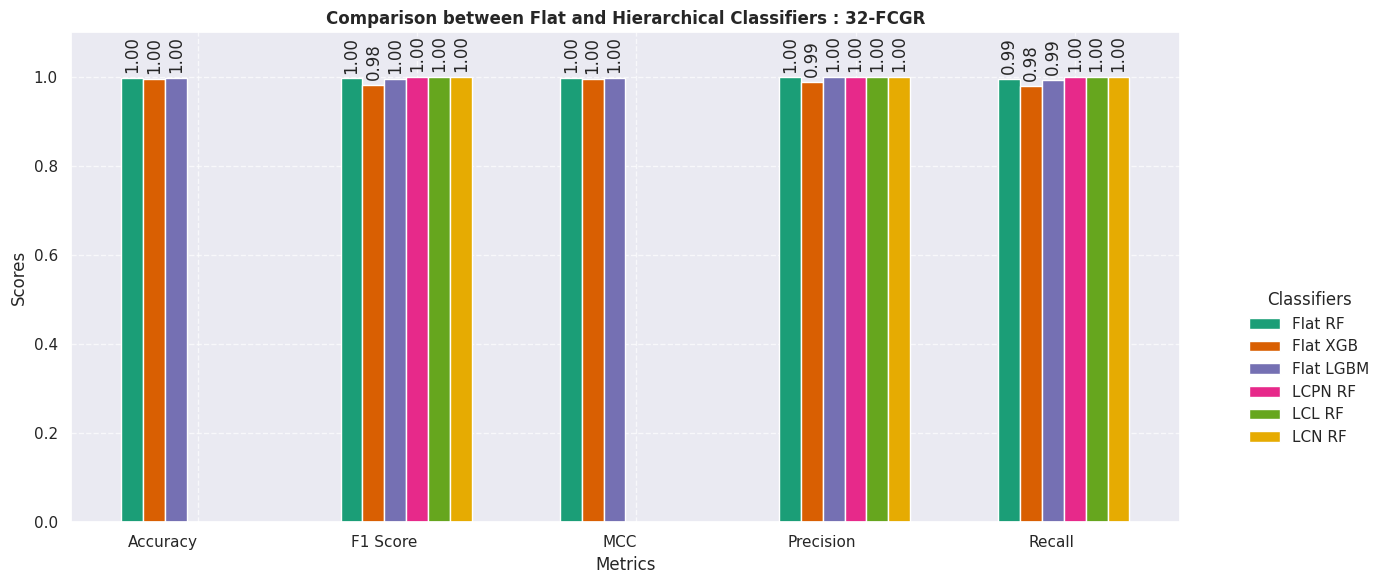

----------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# List of fcgr_values
fcgr_values = [32]
for reso in fcgr_values:
  print(f"Resolution = {reso}")
  train_evaluate_plot_combined_model_fcgr(df, reso,title=f"Comparison between Flat and Hierarchical Classifiers : {reso}-FCGR")
  print(80*"--")

In [ ]:
# @title B.4. Feature importance for resolution = 32 with Random Forest
def feature_importance_rf_fcgr(df, resolution=32):
    # Step 1: Prepare the data
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution)).tolist())
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    y = df['Lineage']

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # Step 3: Train a Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=77,
        max_depth=12,
        min_samples_split=15,
        min_samples_leaf=5,
        bootstrap=True,
        criterion='entropy',
        n_jobs=-1,
        random_state=42)

    rf_model.fit(X_train, y_train)

    # Step 4: Compute feature importance
    importances = rf_model.feature_importances_

    # Step 5: Visualize feature importance
    # Reshape feature importances back to the FCGR grid
    fcgr_importance_grid = importances.reshape((resolution, resolution))
    plt.figure(figsize=(18, 16))

    # Create heatmap
    sns.heatmap(fcgr_importance_grid, cmap='viridis', cbar=True)

    # Invert Y-axis so the origin is at the bottom
    plt.gca().invert_yaxis()
    # plt.gca().invert_xaxis()

    plt.title(f'Feature Importance for FCGR ({resolution}x{resolution}) Grid with Random Forest', fontweight='bold')
    plt.xlabel('X')
    plt.ylabel('Y')

    # Display and save the figure
    plt.savefig("/content/fcgr_32_rf_feature_importance.pdf")
    plt.show()

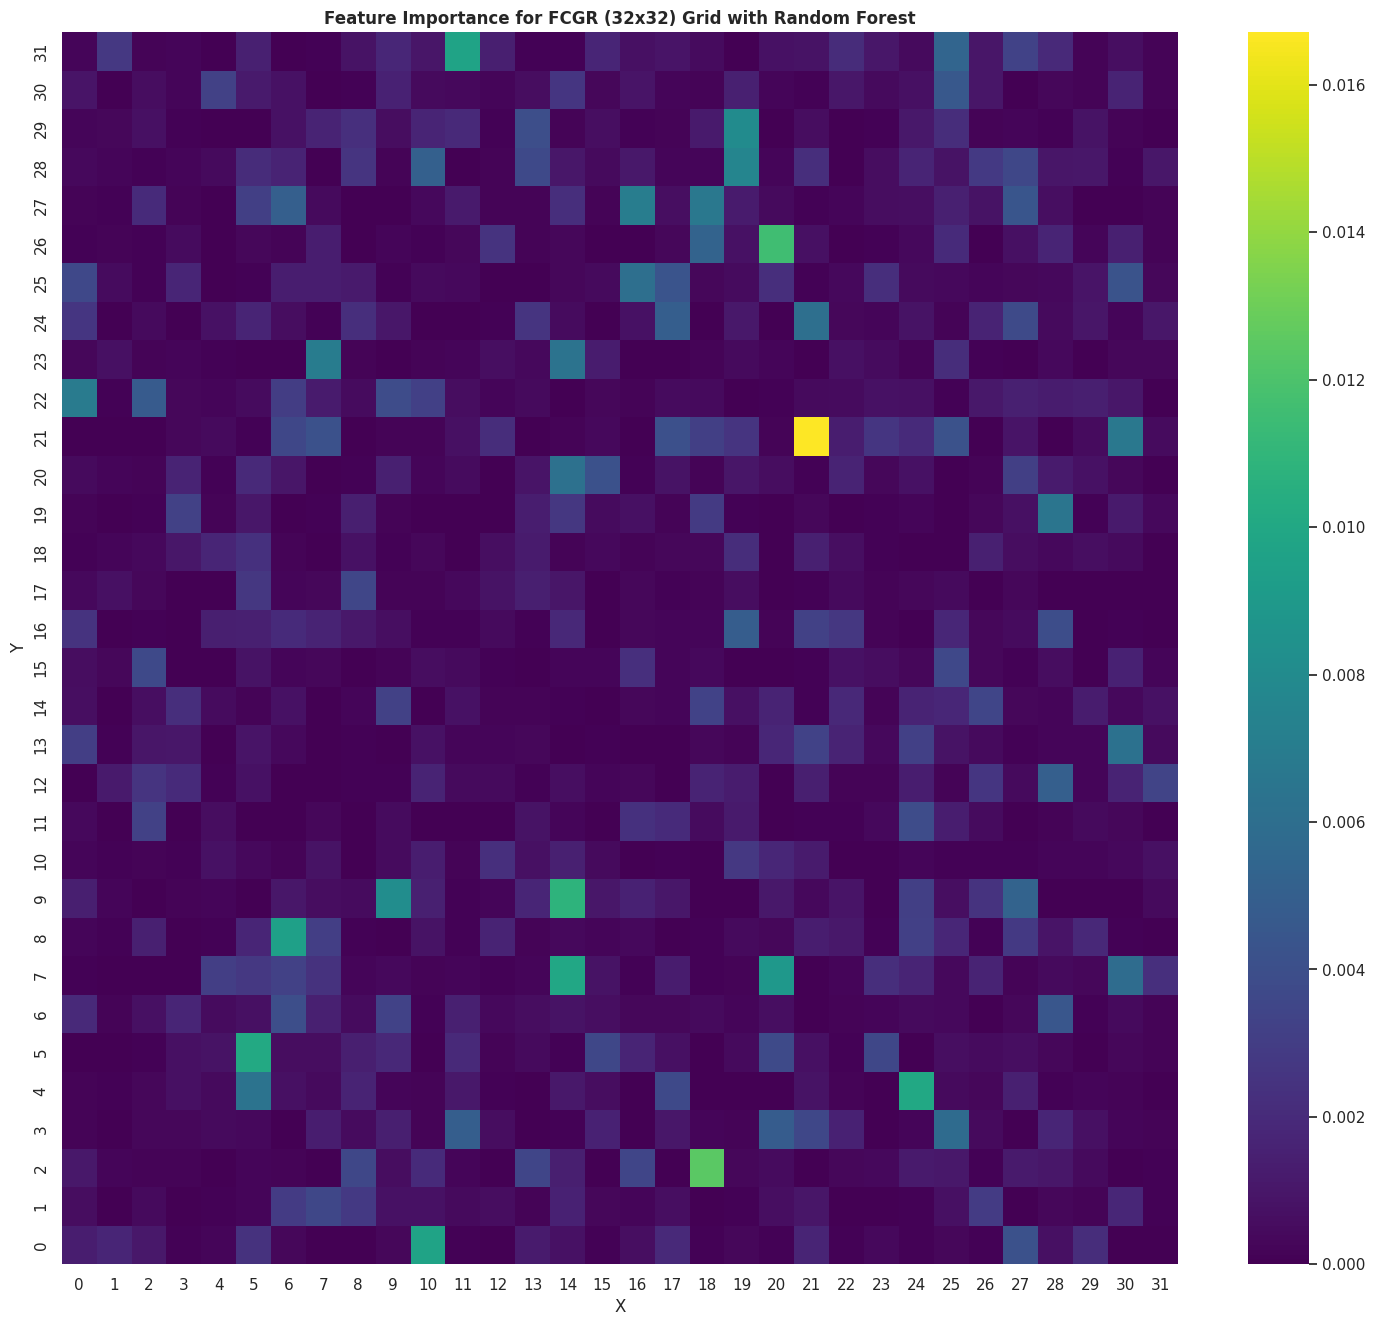

In [ ]:
feature_importance_rf_fcgr(df)

#`III. Save Models`

In [ ]:
#!mkdir -p /content/ML_SAVED_MODELS

# `III.1. 5-mers Feature Extraction Technique`

In [ ]:
# @title A. Save Random Forest 5-mers
def train_evaluate_plot_save_rf_kmodel(df, k=5, fontsize=15, title="Evaluation Metrics",
      save_model_path="/content/ML_SAVED_MODELS/5_MERS/RF_model.joblib", save_encoder_path="/content/ML_SAVED_MODELS/5_MERS/RF_label_encoder.joblib"):

    # Convert sequences to k-mers and apply CountVectorizer
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers'])

    # Convert to float32
    X = X_kmers.astype(np.float32)

    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))

    # Classifiers
    classifiers = {
         'Random Forest': RandomForestClassifier(n_estimators=234,max_depth=19,min_samples_split=17,
                    min_samples_leaf=16,bootstrap=True,criterion='gini', n_jobs=-1, random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Save the trained model
        joblib.dump(clf, save_model_path)
        print(f"Model saved to {save_model_path}")

        # Save the label encoder
        joblib.dump(label_encoder, save_encoder_path)
        print(f"Label encoder saved to {save_encoder_path}")

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifier", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {k}-mers", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/ML_SAVED_MODELS/5_MERS/{clf_name}_{k}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, ax = plt.subplots(figsize=(20, 15))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True,
                    ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 0.8})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/ML_SAVED_MODELS/5_MERS/{clf_name}_{k}_ConfusionMatrix.pdf")

    # Plot confusion matrices
    class_names = label_encoder.classes_

    # XGBoost
    plot_confusion_matrix(ax, y_test, predictions['Random Forest'], class_names, 'Confusion Matrix - Random Forest')
    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})
Model saved to /content/ML_SAVED_MODELS/5_MERS/RF_model.joblib
Label encoder saved to /content/ML_SAVED_MODELS/5_MERS/RF_label_encoder.joblib


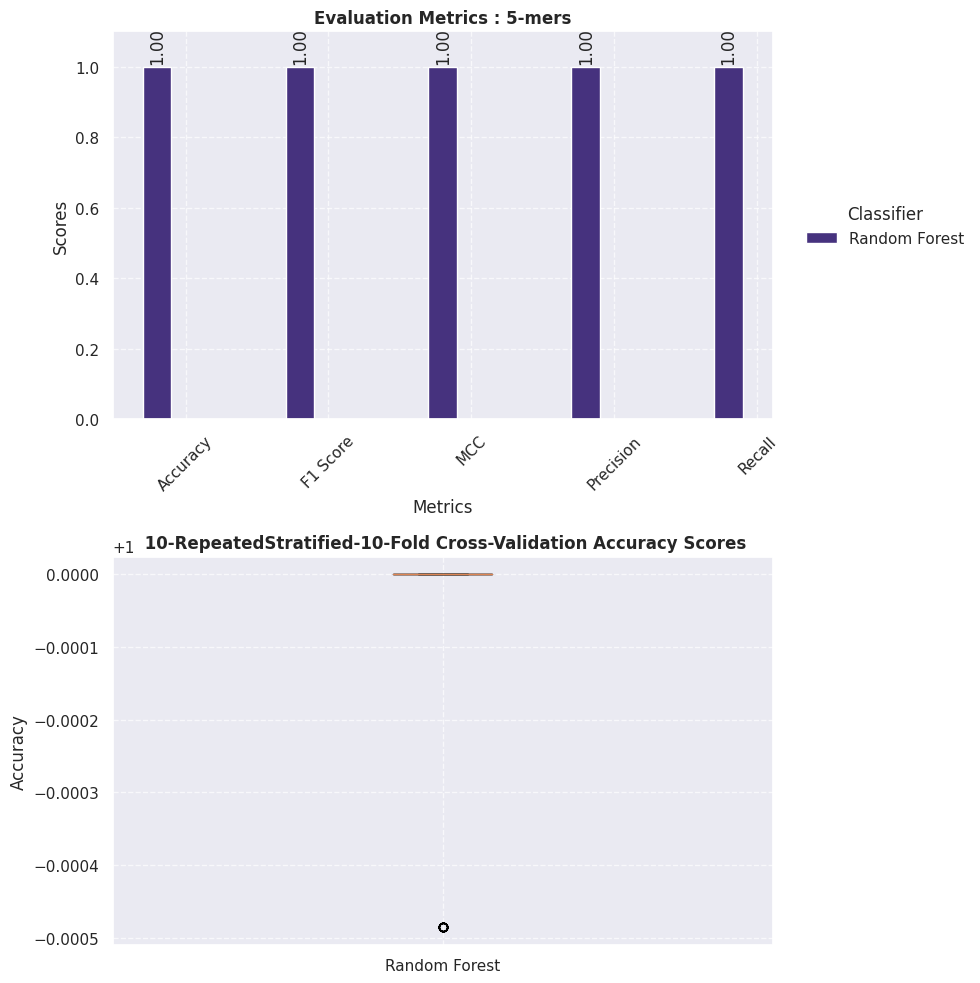

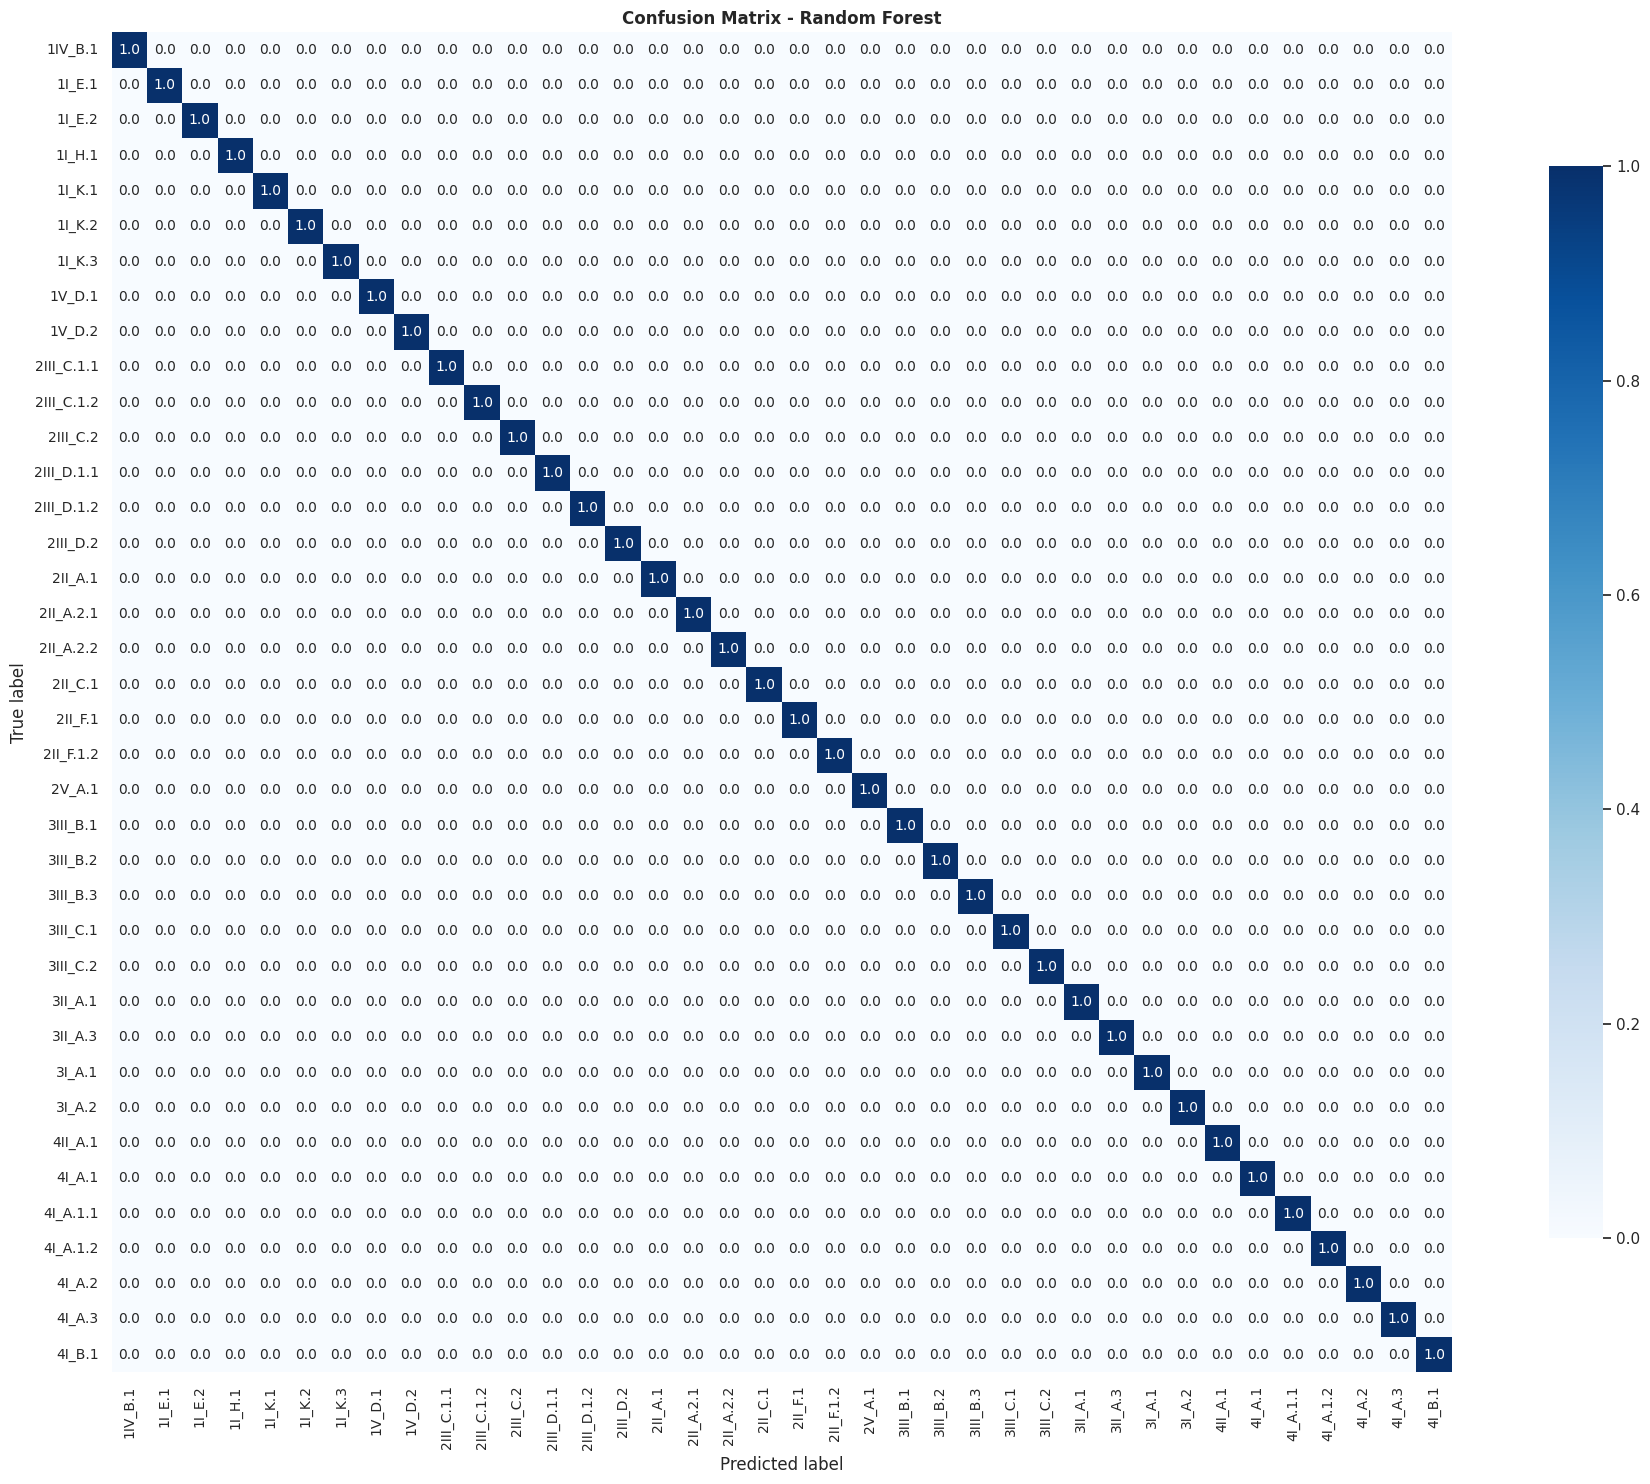

In [ ]:
train_evaluate_plot_save_rf_kmodel(df)

In [ ]:
# @title B. Save  XGBoost 5-mers
def train_evaluate_plot_save_xgb_kmodel(df, k=5, fontsize=15, title="Evaluation Metrics",
      save_model_path="/content/ML_SAVED_MODELS/5_MERS/XGB_model.joblib", save_encoder_path="/content/ML_SAVED_MODELS/5_MERS/XGB_label_encoder.joblib"):

    # Convert sequences to k-mers and apply CountVectorizer
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers'])

    # Convert to float32
    X = X_kmers.astype(np.float32)

    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))

    # Classifiers
    classifiers = {
         'XGBoost': XGBClassifier(max_depth=14,learning_rate=0.0041,n_estimators=345,min_child_weight=1,
                        subsample=0.9751,colsample_bytree=0.8915, n_jobs=-1,random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Save the trained model
        joblib.dump(clf, save_model_path)
        print(f"Model saved to {save_model_path}")

        # Save the label encoder
        joblib.dump(label_encoder, save_encoder_path)
        print(f"Label encoder saved to {save_encoder_path}")

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifier", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {k}-mers", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/ML_SAVED_MODELS/5_MERS/{clf_name}_{k}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, ax = plt.subplots(figsize=(20, 15))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True,
                    ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 1.0})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/ML_SAVED_MODELS/5_MERS/{clf_name}_{k}_ConfusionMatrix.pdf")

    # Plot confusion matrices
    class_names = label_encoder.classes_

    # XGBoost
    plot_confusion_matrix(ax, y_test, predictions['XGBoost'], class_names, 'Confusion Matrix - XGBoost')
    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})
Model saved to /content/ML_SAVED_MODELS/5_MERS/XGB_model.joblib
Label encoder saved to /content/ML_SAVED_MODELS/5_MERS/XGB_label_encoder.joblib


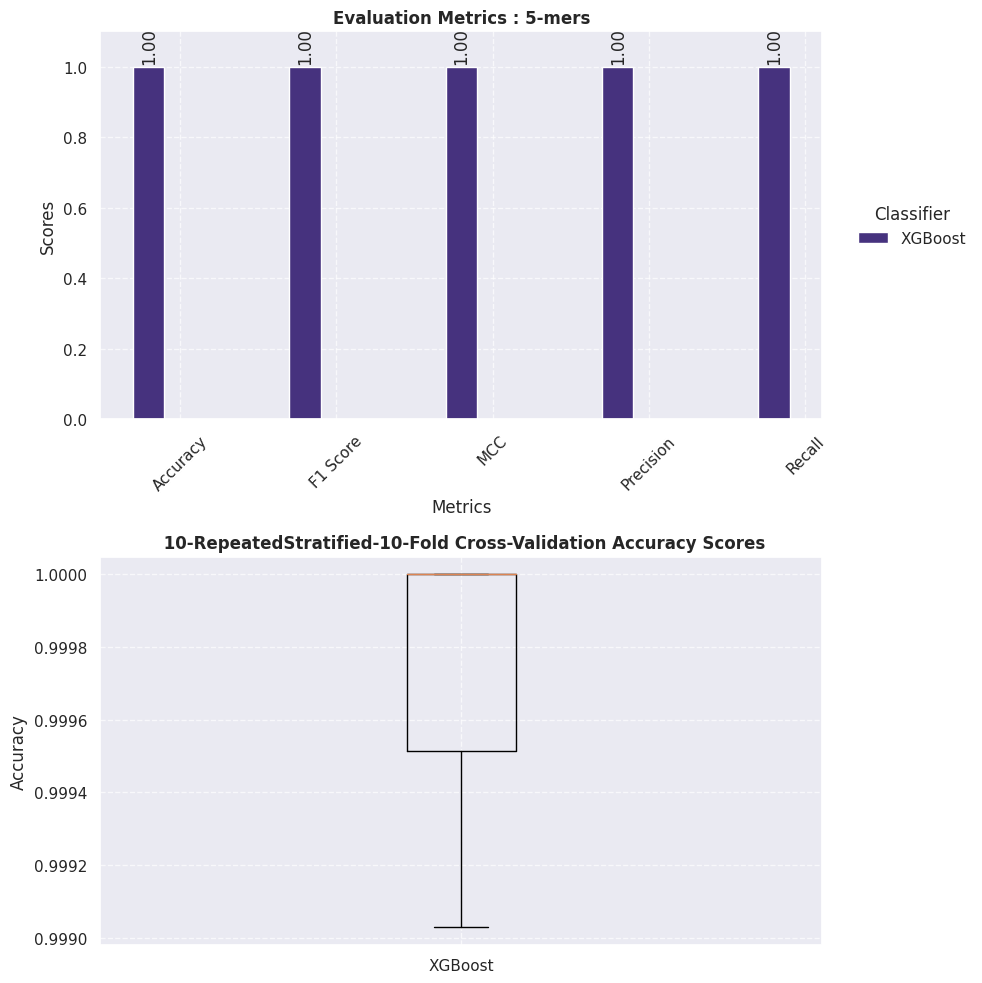

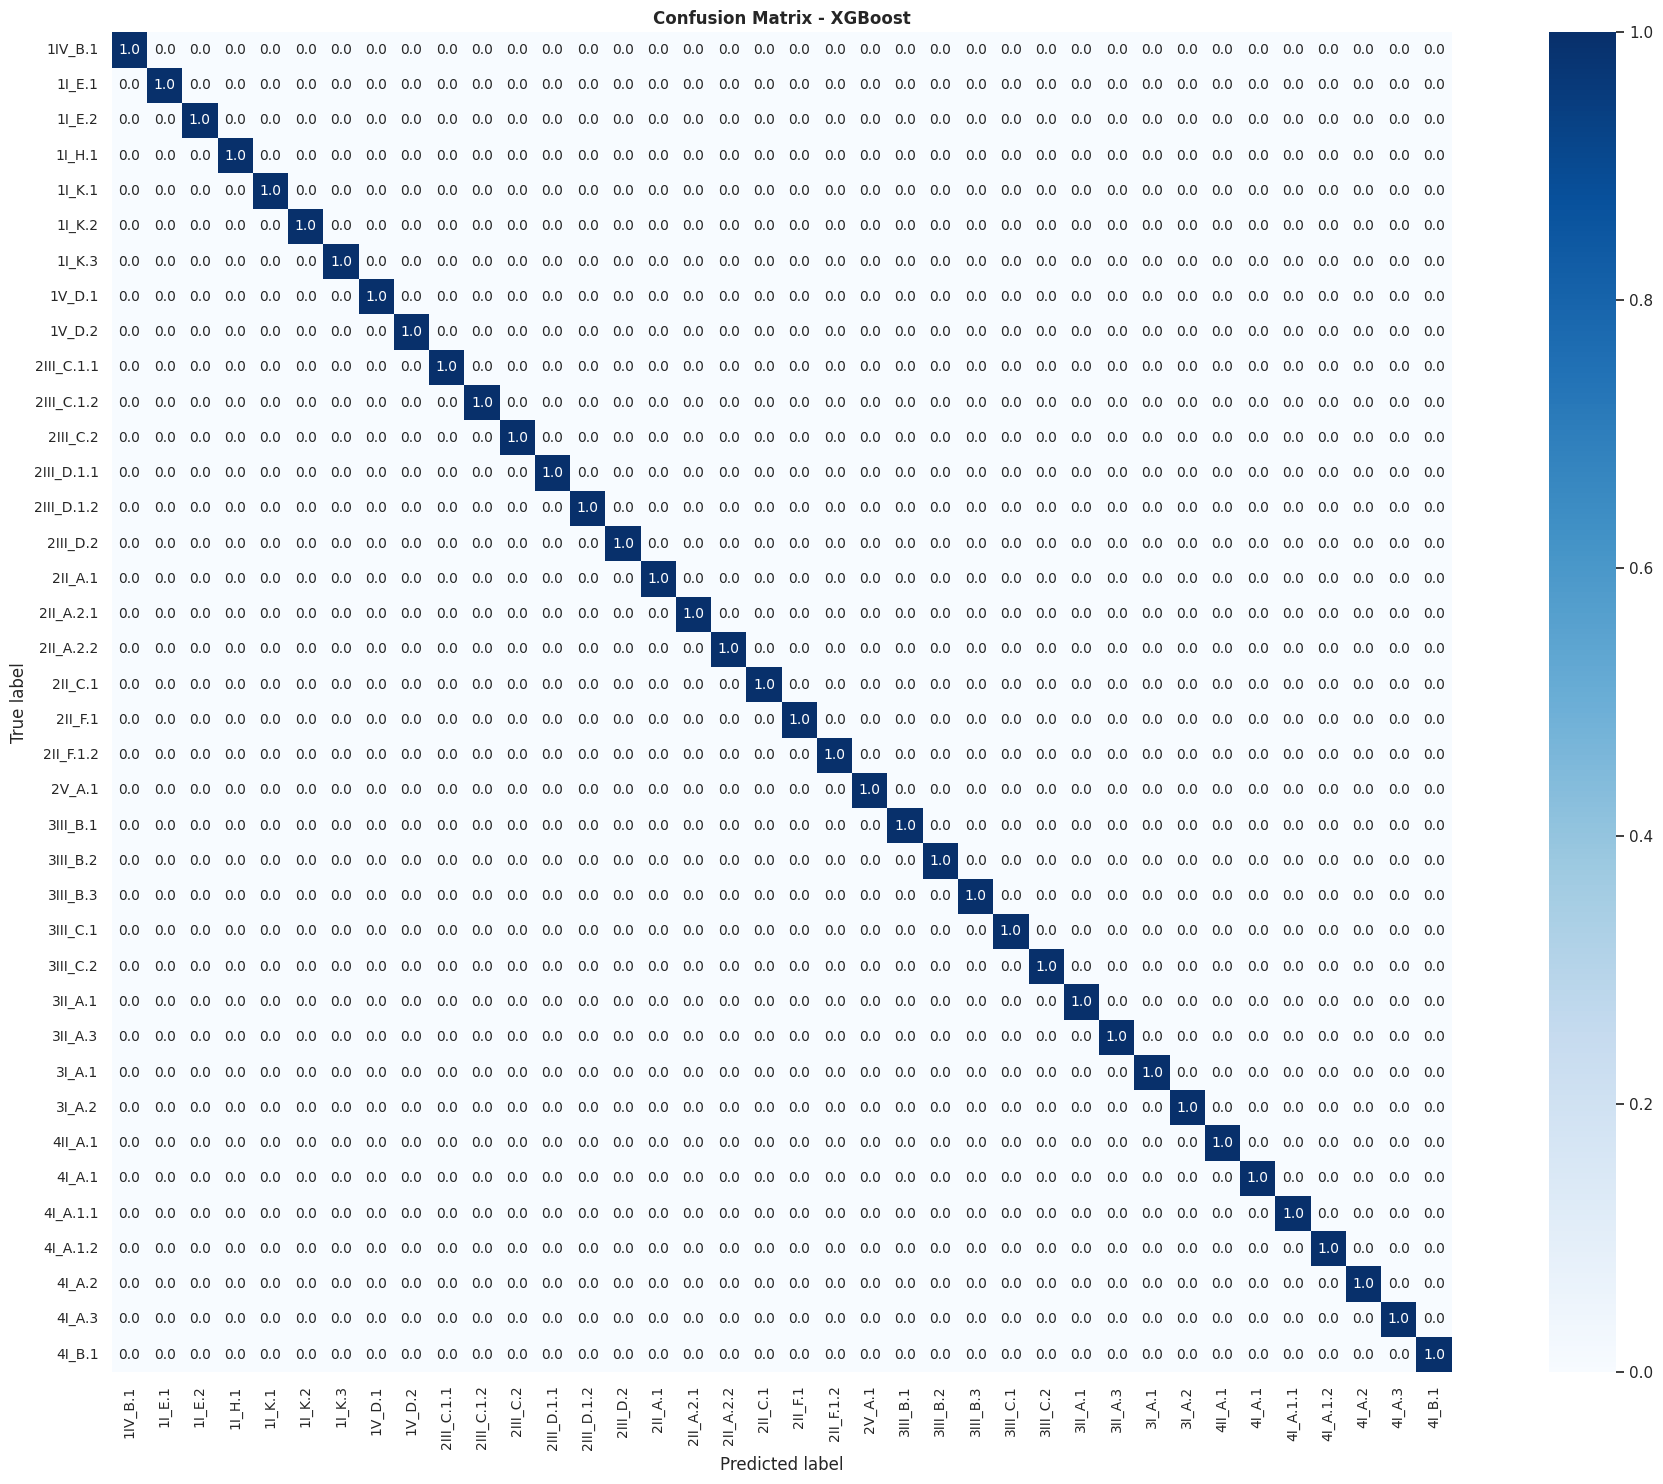

In [ ]:
train_evaluate_plot_save_xgb_kmodel(df)

In [ ]:
# @title C. Save LightGBM 5-mers
def train_evaluate_plot_save_lgbm_kmodel(df, k=5, fontsize=15, title="Evaluation Metrics",
      save_model_path="/content/ML_SAVED_MODELS/5_MERS/LGBM_model.joblib", save_encoder_path="/content/ML_SAVED_MODELS/5_MERS/LGBM_label_encoder.joblib"):

    # Convert sequences to k-mers and apply CountVectorizer
    df['kmers'] = df['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df['kmers'])

    # Convert to float32
    X = X_kmers.astype(np.float32)

    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))

    # Classifiers
    classifiers = {
         'LightGBM': lgb.LGBMClassifier(learning_rate=0.034,n_estimators=458, max_depth=0,num_leaves=247,
                          feature_fraction=0.6218,bagging_fraction=0.8951,
                        bagging_freq=3,min_child_samples=8, lambda_l1= 7.5168e-06, lambda_l2=0.0039,
                                  objective='multiclass',verbose=-1, n_jobs=-1,random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Save the trained model
        joblib.dump(clf, save_model_path)
        print(f"Model saved to {save_model_path}")

        # Save the label encoder
        joblib.dump(label_encoder, save_encoder_path)
        print(f"Label encoder saved to {save_encoder_path}")

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifier", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {k}-mers", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/ML_SAVED_MODELS/5_MERS/{clf_name}_{k}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, ax = plt.subplots(figsize=(20, 15))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True,
                    ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 1.0})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/ML_SAVED_MODELS/5_MERS/{clf_name}_{k}_ConfusionMatrix.pdf")

    # Plot confusion matrices
    class_names = label_encoder.classes_

    # XGBoost
    plot_confusion_matrix(ax, y_test, predictions['LightGBM'], class_names, 'Confusion Matrix - LightGBM')
    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})
Model saved to /content/ML_SAVED_MODELS/5_MERS/LGBM_model.joblib
Label encoder saved to /content/ML_SAVED_MODELS/5_MERS/LGBM_label_encoder.joblib


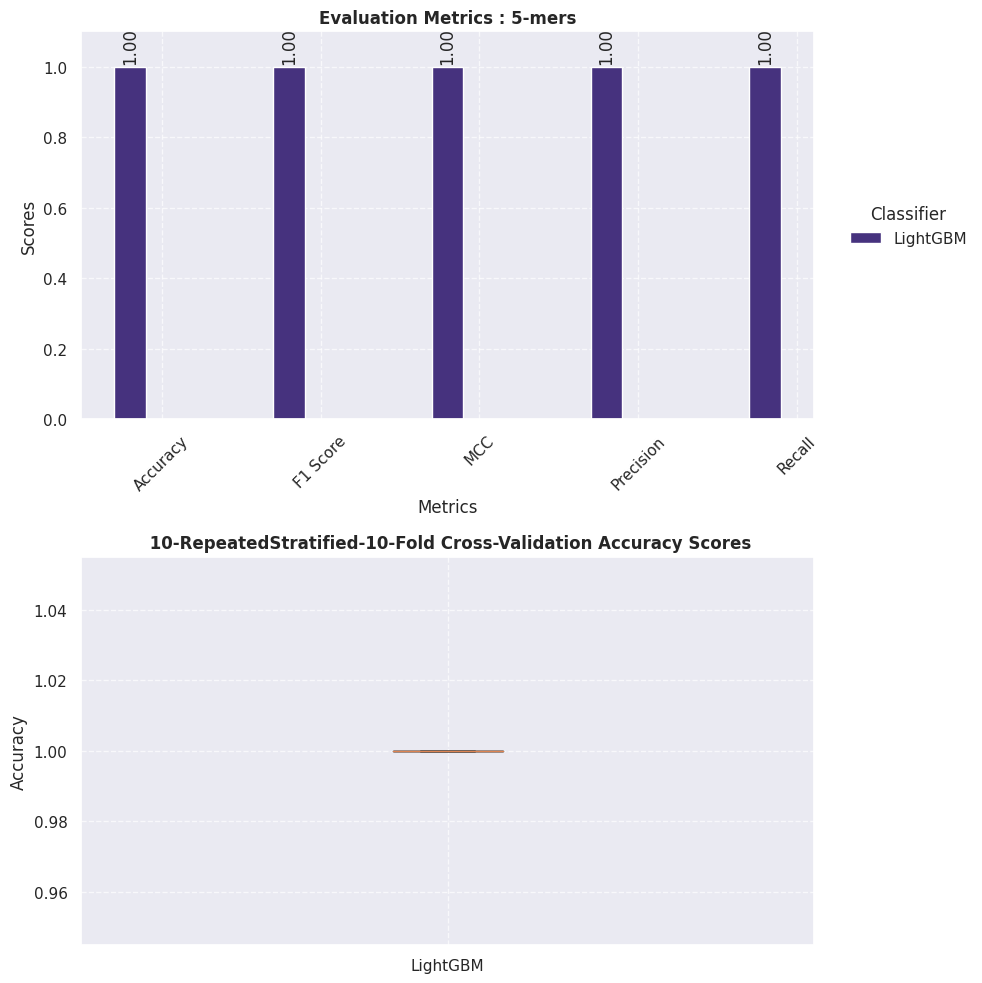

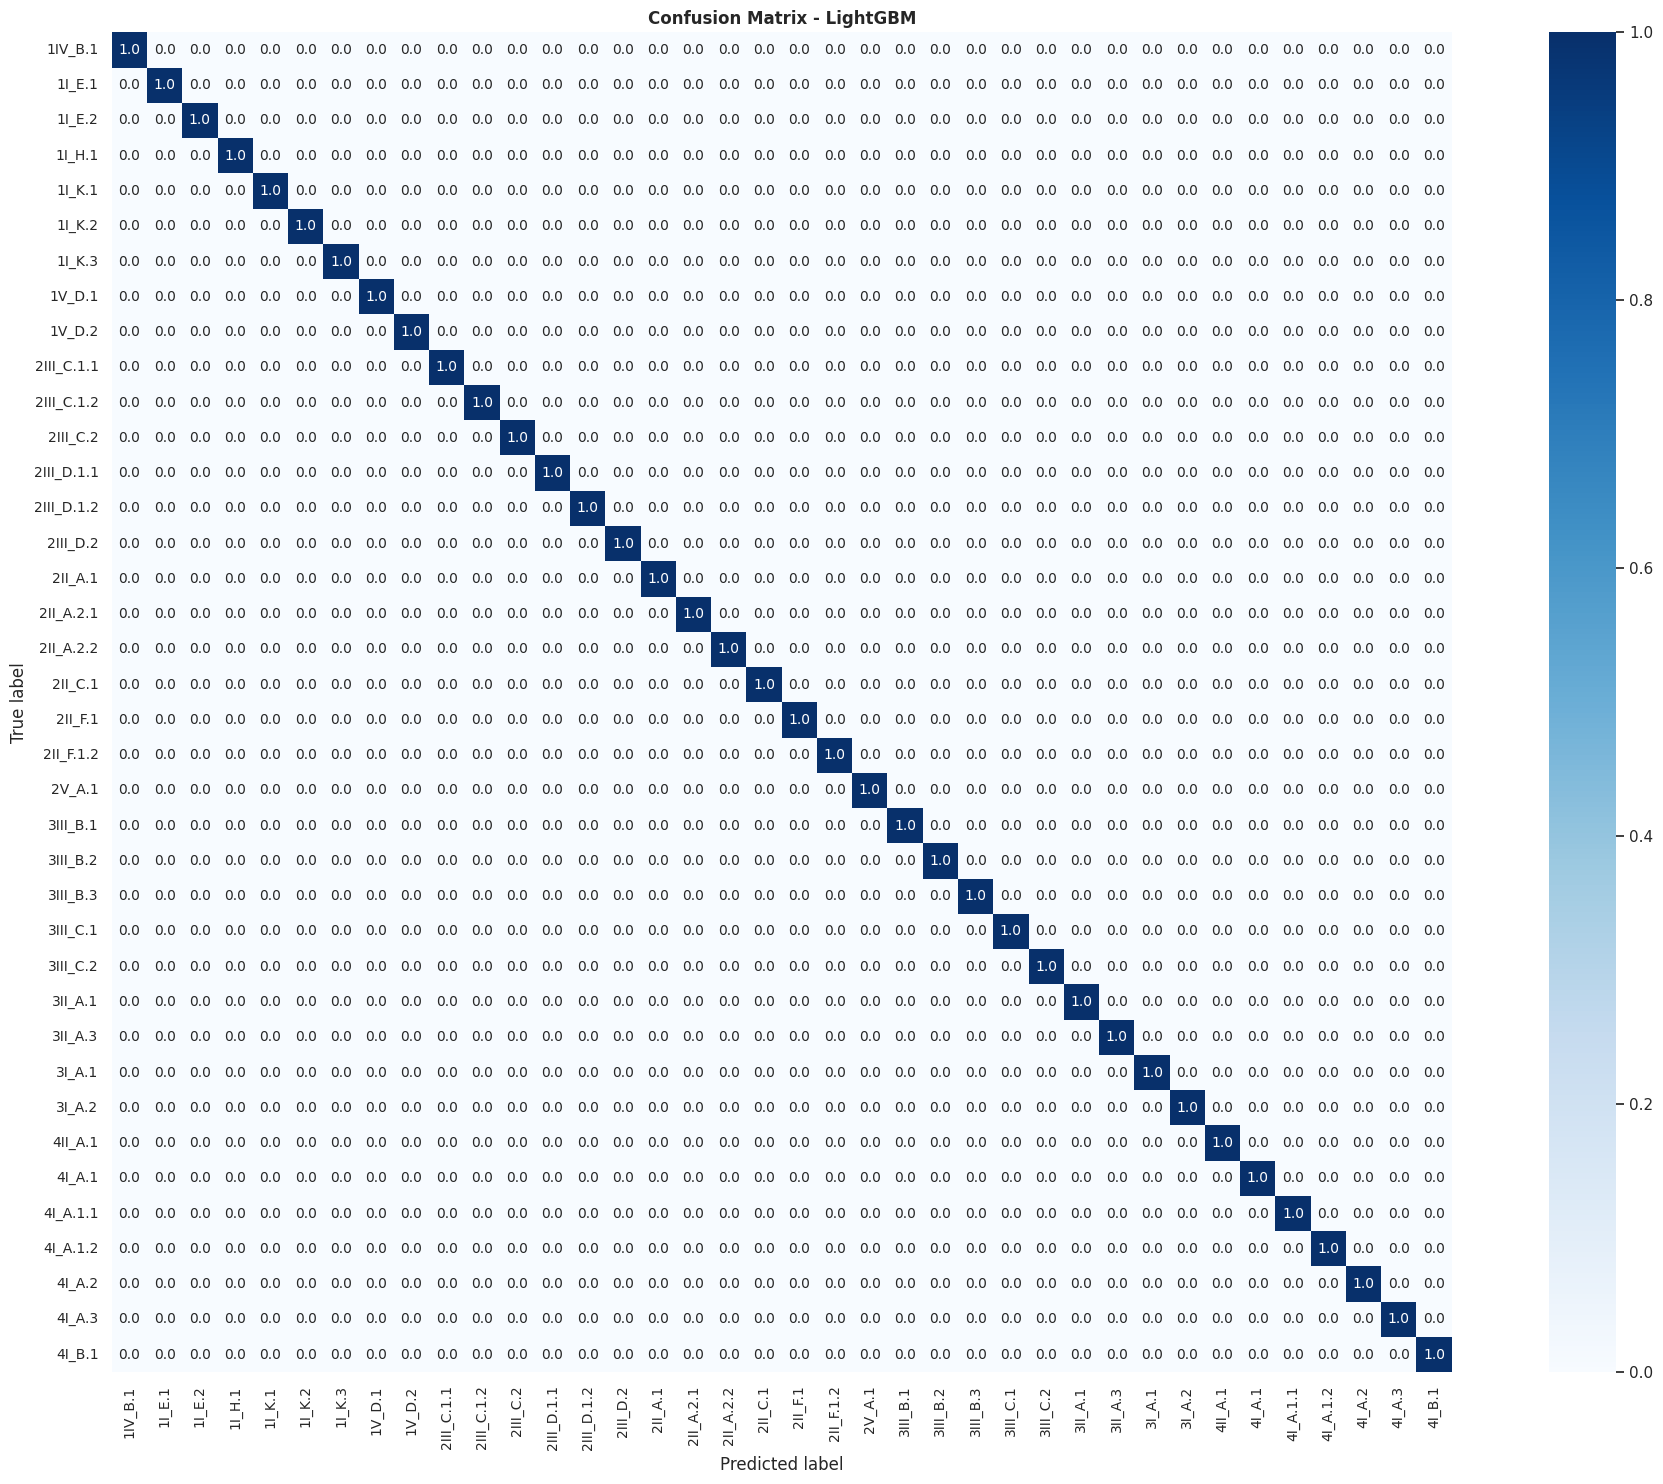

In [ ]:
train_evaluate_plot_save_lgbm_kmodel(df)

# `III.2. 32-FCGR Feature Extraction Technique`

In [ ]:
# @title A. Save Random Forest 32-FCGR
def train_evaluate_plot_save_rf_fcgrmodel(df, resolution_=32, fontsize=15, title="Evaluation Metrics",
      save_model_path="/content/ML_SAVED_MODELS/32_FCGR/RF_FCGR_model.joblib", save_encoder_path="/content/ML_SAVED_MODELS/32_FCGR/RF_FCGR_label_encoder.joblib"):

    # Convert sequences to a 2D CGR-based feature extraction
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

    # Convert to float32
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))

    # Classifiers
    classifiers = {
         'Random Forest': RandomForestClassifier(n_estimators=77,max_depth=12,min_samples_split=15,
                          min_samples_leaf=5,bootstrap=True,criterion='entropy', n_jobs=-1, random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Save the trained model
        joblib.dump(clf, save_model_path)
        print(f"Model saved to {save_model_path}")

        # Save the label encoder
        joblib.dump(label_encoder, save_encoder_path)
        print(f"Label encoder saved to {save_encoder_path}")

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifier", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {resolution_}-FCGR", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/ML_SAVED_MODELS/32_FCGR/{clf_name}_{resolution_}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, ax = plt.subplots(figsize=(20, 15))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True,
                    ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 1.0})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/ML_SAVED_MODELS/32_FCGR/{clf_name}_{resolution_}_ConfusionMatrix.pdf")

    # Plot confusion matrices
    class_names = label_encoder.classes_

    # XGBoost
    plot_confusion_matrix(ax, y_test, predictions['Random Forest'], class_names, 'Confusion Matrix - Random Forest')
    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})
Model saved to /content/ML_SAVED_MODELS/32_FCGR/RF_FCGR_model.joblib
Label encoder saved to /content/ML_SAVED_MODELS/32_FCGR/RF_FCGR_label_encoder.joblib


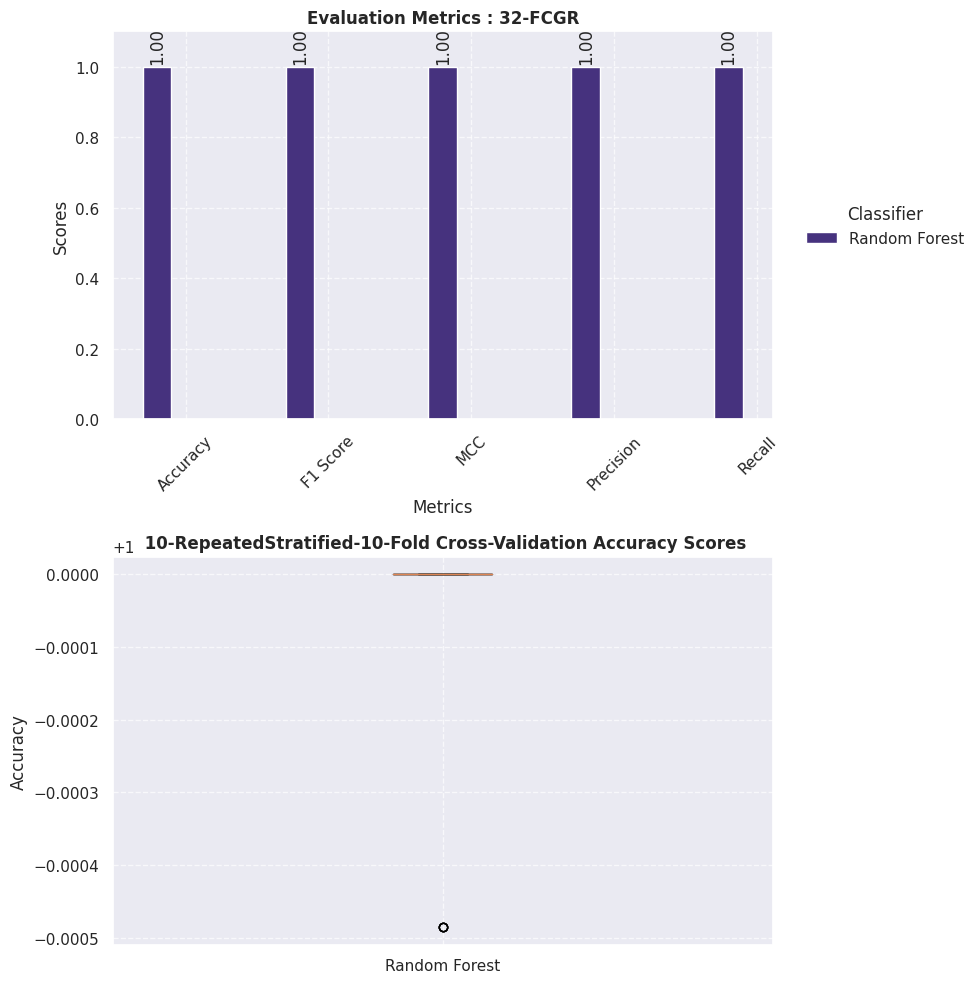

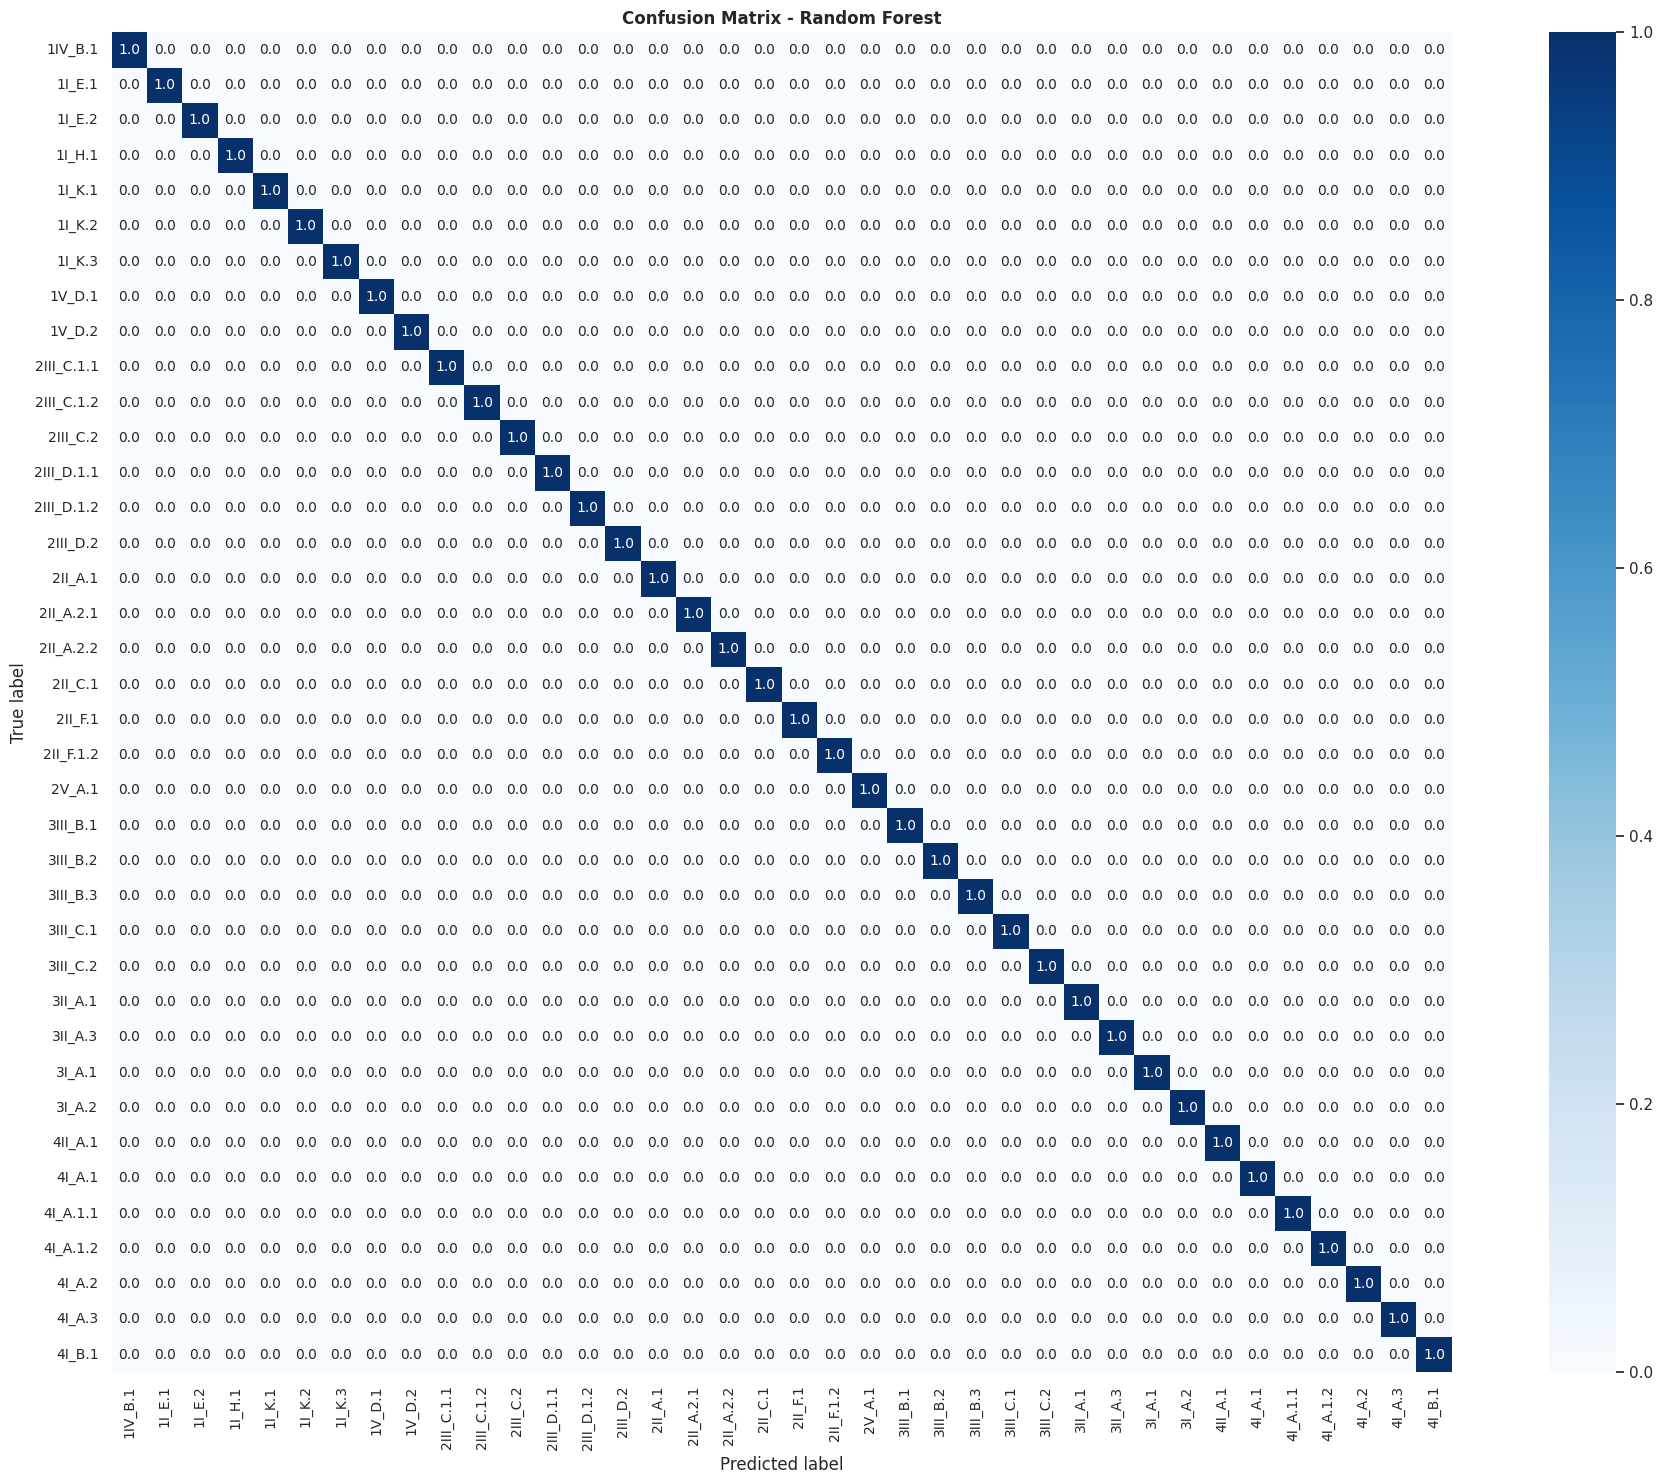

In [ ]:
train_evaluate_plot_save_rf_fcgrmodel(df)

In [ ]:
# @title B. Save XGBoost 32-FCGR
def train_evaluate_plot_save_xgb_fcgrmodel(df, resolution_=32, fontsize=15, title="Evaluation Metrics",
      save_model_path="/content/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_model.joblib", save_encoder_path="/content/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_label_encoder.joblib"):

    # Convert sequences to a 2D CGR-based feature extraction
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

    # Convert to float32
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))

    # Classifiers
    classifiers = {
          'XGBoost': XGBClassifier(max_depth=15,learning_rate=0.0271,n_estimators=253,min_child_weight=9,
                                 subsample=0.6411,colsample_bytree=0.5212, n_jobs=-1,random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Save the trained model
        joblib.dump(clf, save_model_path)
        print(f"Model saved to {save_model_path}")

        # Save the label encoder
        joblib.dump(label_encoder, save_encoder_path)
        print(f"Label encoder saved to {save_encoder_path}")

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifier", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {resolution_}-FCGR", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/ML_SAVED_MODELS/32_FCGR/{clf_name}_{resolution_}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, ax = plt.subplots(figsize=(20, 15))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True,
                    ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 1.0})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/ML_SAVED_MODELS/32_FCGR/{clf_name}_{resolution_}_ConfusionMatrix.pdf")

    # Plot confusion matrices
    class_names = label_encoder.classes_

    # XGBoost
    plot_confusion_matrix(ax, y_test, predictions['XGBoost'], class_names, 'Confusion Matrix - XGBoost')
    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})
Model saved to /content/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_model.joblib
Label encoder saved to /content/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_label_encoder.joblib


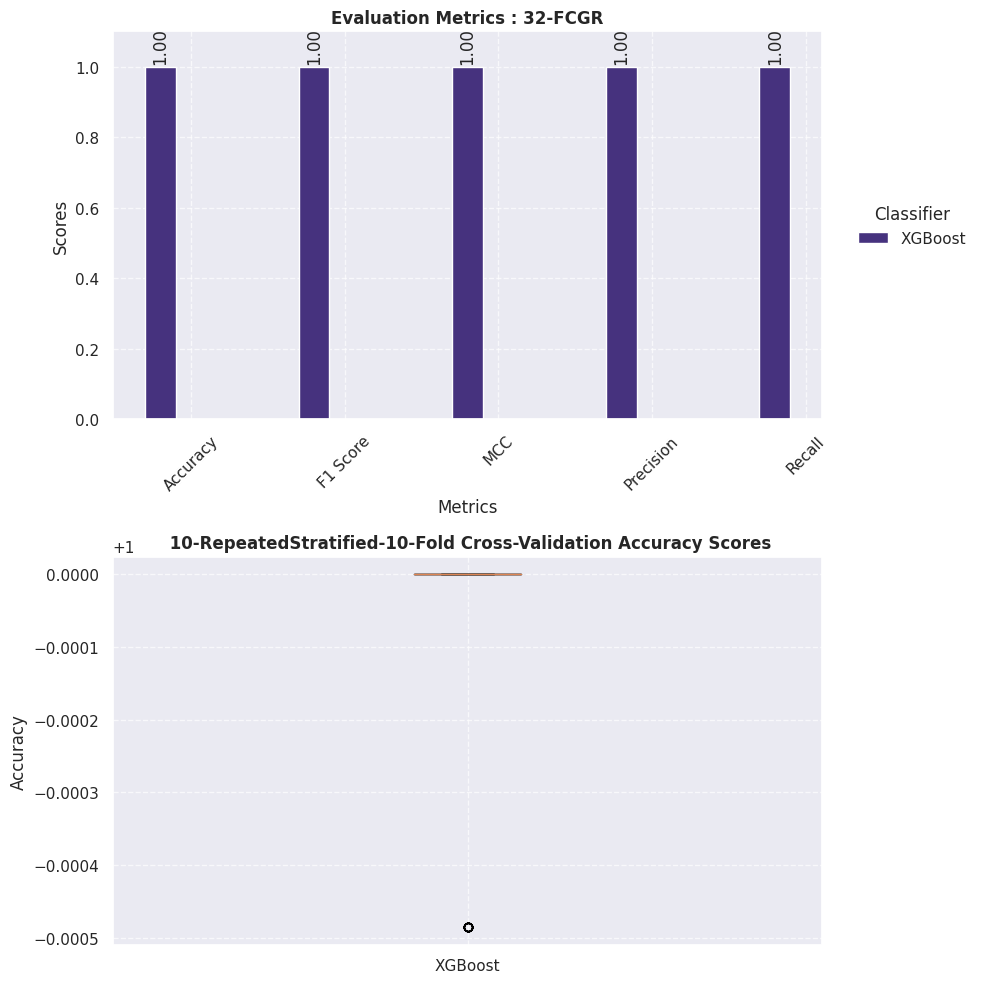

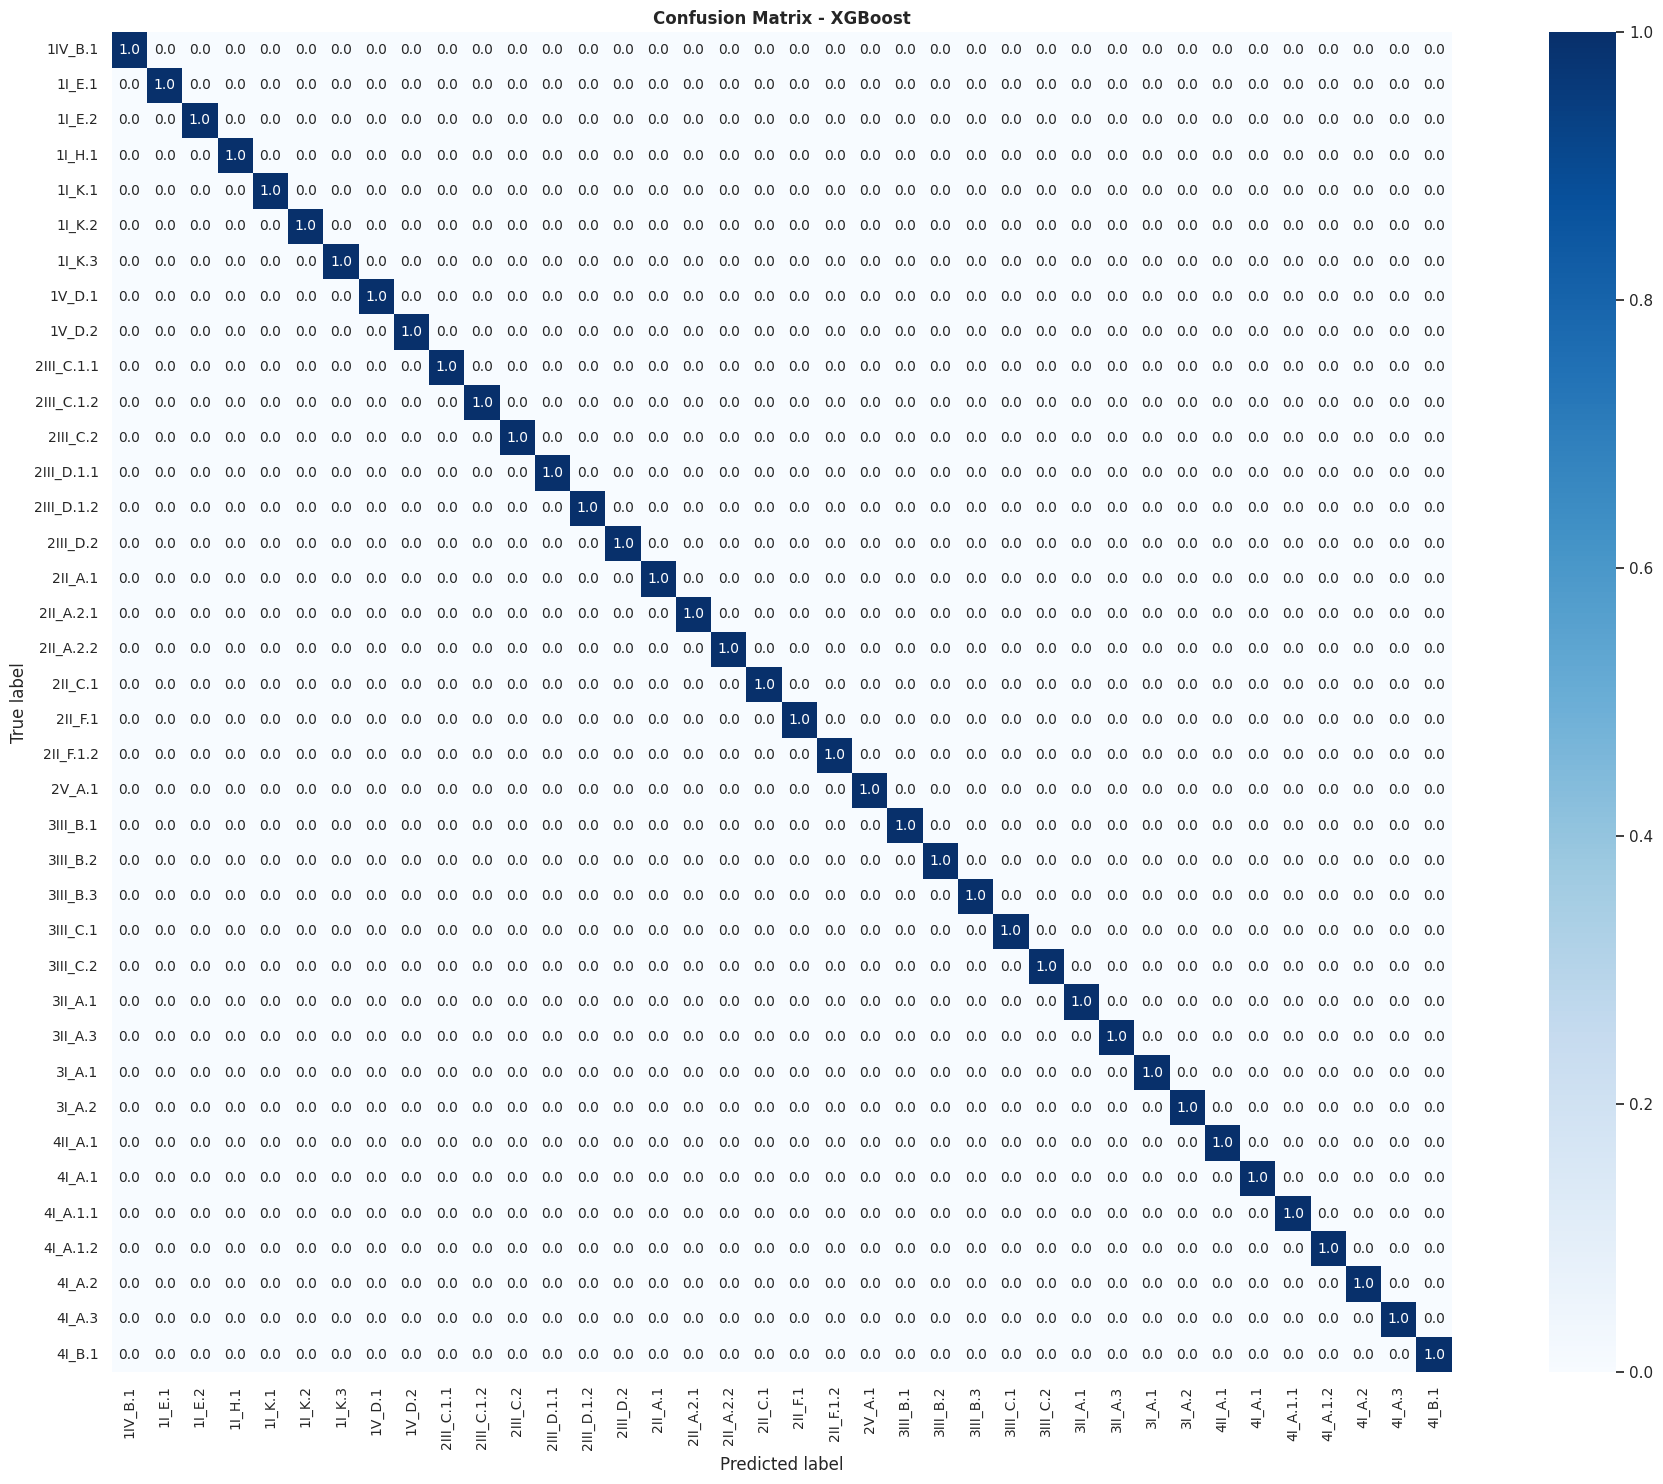

In [ ]:
train_evaluate_plot_save_xgb_fcgrmodel(df)

In [ ]:
# @title C. Save Random LGBM 32-FCGR
def train_evaluate_plot_save_lgbm_fcgrmodel(df, resolution_=32, fontsize=15, title="Evaluation Metrics",
      save_model_path="/content/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_model.joblib", save_encoder_path="/content/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_label_encoder.joblib"):

    # Convert sequences to a 2D CGR-based feature extraction
    X_fcgr = np.array(df['Sequence'].apply(lambda x: fcgr(x, resolution=resolution_)).tolist())

    # Convert to float32
    X_fcgr = X_fcgr.astype(np.float32)
    X = X_fcgr

    # Make labels in a confortable form :
    label_encoder = LabelEncoder()
    df['Lineage_Label'] = label_encoder.fit_transform(df['Lineage'])
    y = df['Lineage_Label']

    print("Original class distribution:")
    print(Counter(y))

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print resampled class distribution
    print("\nResampled class distribution:")
    print(Counter(y_train_resampled))

    # Classifiers
    classifiers = {
        'LightGBM': lgb.LGBMClassifier(learning_rate=0.0870,n_estimators=836, max_depth=1,num_leaves=26,
                                       feature_fraction=0.8267 ,bagging_fraction=0.5361,
                                      bagging_freq=1,min_child_samples=25, lambda_l1= 0.0008, lambda_l2=1.0356e-06,objective='multiclass',
                                       verbose=-1, n_jobs=-1,random_state=42)
    }

    # Metrics
    metrics = {
        'Accuracy': accuracy_score,
        'F1 Score': f1_score,
        'MCC': matthews_corrcoef,
        'Precision': precision_score,
        'Recall': recall_score
    }

    # Collect scores and predictions
    scores = {name: [] for name in metrics.keys()}
    cv_scores = {name: [] for name in classifiers.keys()}
    predictions = {}

    # Create StratifiedKFold object
    skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    for clf_name, clf in classifiers.items():
        # Perform stratified k-fold cross-validation
        cv_score = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=skf, scoring='accuracy')
        cv_scores[clf_name] = cv_score

        # Fit the model on the entire training set
        clf.fit(X_train_resampled, y_train_resampled)

        # Save the trained model
        joblib.dump(clf, save_model_path)
        print(f"Model saved to {save_model_path}")

        # Save the label encoder
        joblib.dump(label_encoder, save_encoder_path)
        print(f"Label encoder saved to {save_encoder_path}")

        # Make predictions
        y_pred = clf.predict(X_test)

        predictions[clf_name] = y_pred
        for metric_name, metric in metrics.items():
            if metric_name in ['F1 Score', 'Precision', 'Recall']:
                scores[metric_name].append(metric(y_test, y_pred, average='macro', zero_division=0))
            else:
                scores[metric_name].append(metric(y_test, y_pred))

    # Plotting
    sns.set_theme()

    # Figure 1: Evaluation Metrics
    fig1 = plt.figure(figsize=(10, 10))
    ax_main = fig1.add_subplot(2, 1, 1)
    ax_cv = fig1.add_subplot(2, 1, 2)

    bar_width = 0.2
    index = np.arange(len(metrics))

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        ax_main.bar(index + i * bar_width, [scores[metric][i] for metric in metrics.keys()],
                    bar_width, label=clf_name, color=sns.color_palette('viridis')[i])

    ax_main.set_xlabel('Metrics')
    ax_main.set_ylabel('Scores')
    ax_main.set_xticks(index + bar_width)
    ax_main.set_xticklabels(metrics.keys(), rotation=45)
    ax_main.legend(title="Classifier", bbox_to_anchor=(1.03, 0.5), loc="center left", frameon=False)
    ax_main.set_title(f"Evaluation Metrics : {resolution_}-FCGR", fontsize=12, fontweight='bold')

    for i, (clf_name, clf) in enumerate(classifiers.items()):
        for j, metric in enumerate(metrics.keys()):
            ax_main.text(j + i * bar_width, scores[metric][i] + 0.02, f'{scores[metric][i]:.2f}', ha='center', rotation=90)

    ax_main.set_ylim(0, 1.1)
    ax_main.grid(linestyle="--", alpha=0.7)

    # Plot CV scores
    ax_cv.boxplot([cv_scores[clf] for clf in classifiers.keys()], labels=classifiers.keys())
    ax_cv.set_title(' 10-RepeatedStratified-10-Fold Cross-Validation Accuracy Scores',fontweight='bold')
    ax_cv.set_ylabel('Accuracy')
    ax_cv.grid(linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/content/ML_SAVED_MODELS/32_FCGR/{clf_name}_{resolution_}_Metrics.pdf")
    plt.show()

    # Figure 2: Confusion Matrices
    fig2, ax = plt.subplots(figsize=(20, 15))

    # Function to plot confusion matrix
    def plot_confusion_matrix(ax, y_true, y_pred, classes, title):
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', square=True,
                    ax=ax, annot_kws={'size': 10},cbar_kws={"shrink": 1.0})

        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(title,fontweight='bold')

        ax.set_xticks(np.arange(len(classes)) + 0.5)
        ax.set_yticks(np.arange(len(classes)) + 0.5)
        ax.set_xticklabels(classes, fontsize=10, rotation=90)
        ax.set_yticklabels(classes, fontsize=10, rotation=0)
        # Save and show the figure
        plt.savefig(f"/content/ML_SAVED_MODELS/32_FCGR/{clf_name}_{resolution_}_ConfusionMatrix.pdf")

    # Plot confusion matrices
    class_names = label_encoder.classes_

    # XGBoost
    plot_confusion_matrix(ax, y_test, predictions['LightGBM'], class_names, 'Confusion Matrix - LightGBM')
    plt.tight_layout()
    plt.show()

Original class distribution:
Counter({7: 678, 24: 520, 1: 420, 19: 314, 20: 291, 4: 202, 9: 92, 33: 89, 17: 80, 21: 72, 3: 59, 25: 51, 18: 47, 6: 45, 11: 43, 28: 38, 14: 36, 8: 36, 10: 32, 15: 32, 5: 27, 22: 27, 2: 27, 36: 26, 30: 26, 32: 25, 29: 23, 27: 19, 23: 18, 34: 18, 13: 17, 37: 16, 26: 14, 12: 14, 0: 14, 35: 14, 16: 14, 31: 11})

Resampled class distribution:
Counter({1: 542, 20: 542, 7: 542, 19: 542, 9: 542, 24: 542, 22: 542, 5: 542, 34: 542, 37: 542, 4: 542, 3: 542, 32: 542, 21: 542, 17: 542, 18: 542, 26: 542, 2: 542, 13: 542, 36: 542, 30: 542, 25: 542, 33: 542, 28: 542, 0: 542, 35: 542, 10: 542, 15: 542, 31: 542, 8: 542, 16: 542, 6: 542, 14: 542, 23: 542, 29: 542, 11: 542, 27: 542, 12: 542})
Model saved to /content/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_model.joblib
Label encoder saved to /content/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_label_encoder.joblib


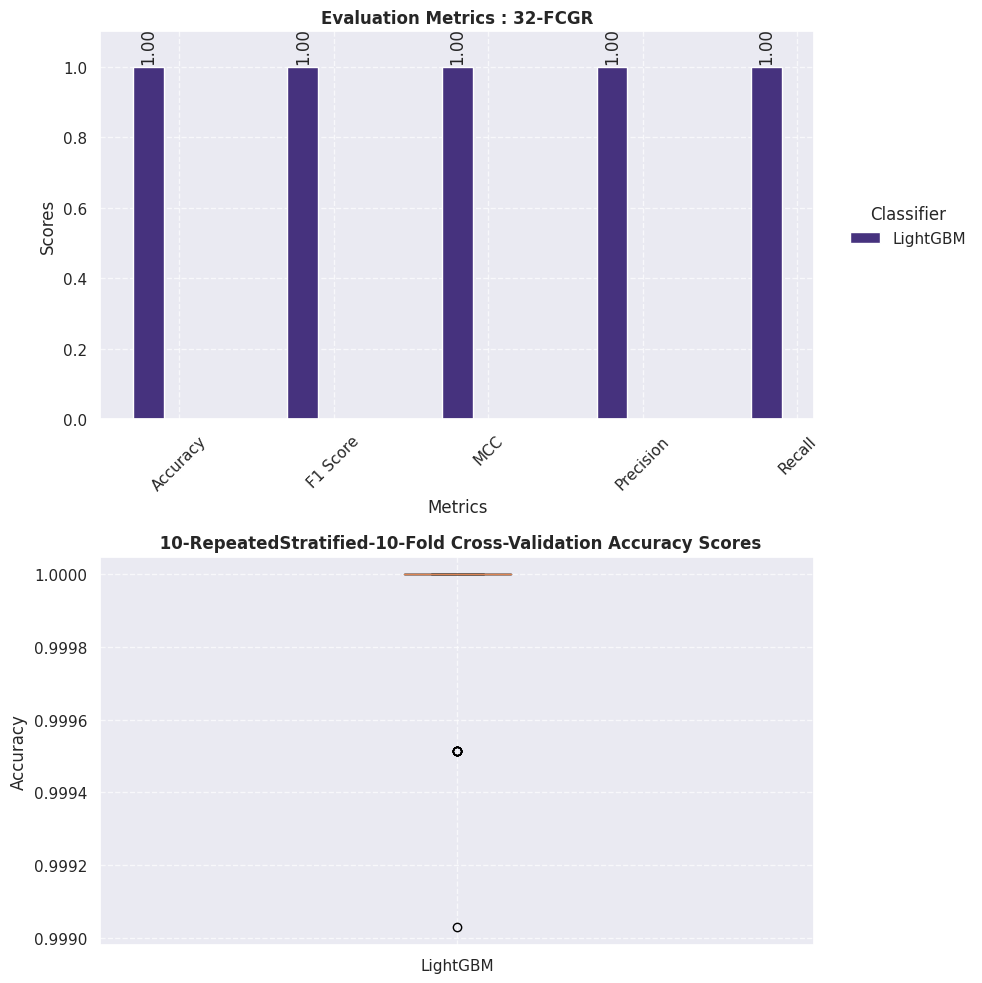

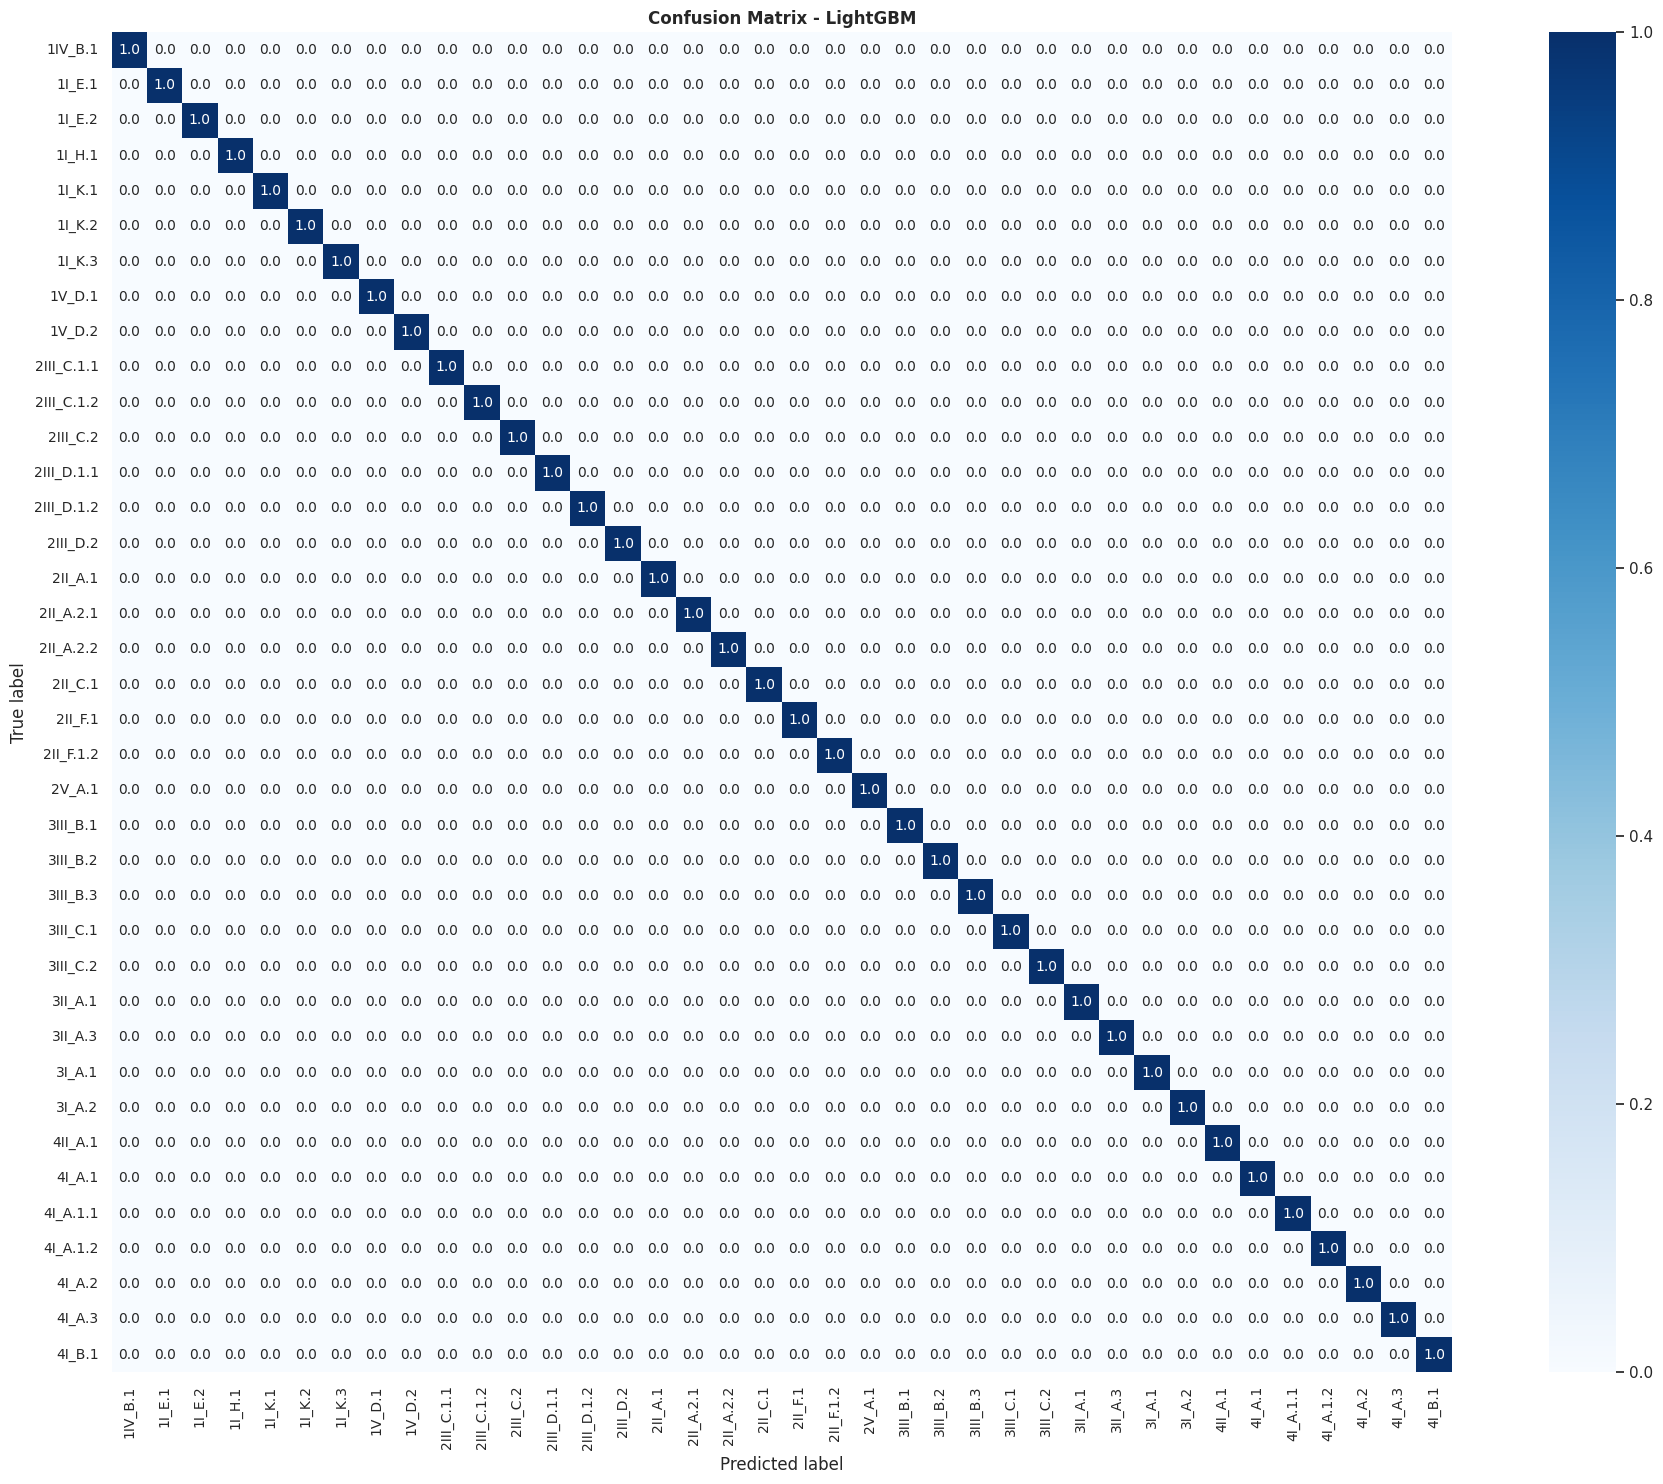

In [ ]:
train_evaluate_plot_save_lgbm_fcgrmodel(df)